**Author:** Lennox Anderson
<br>
**Last Updated:** 2025-09-14

In [32]:
!pip install ultralytics

INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 33.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 MB 58.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: torch━━━━━━━━━━━━━━━━━━━ 0/4 [opencv-python]
    Found existing installation: torch 2.3.1 0/4 [opencv-python]
    Uninstalling torch-2.3.1:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/4 [torch]
      Successfully uninstalled torch-2.3.1━━━━━━━━━━━━━━━━━━━━ 1/4 [torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ultralytics] [ultralytics]


## **SCREEN DIMENSIONS EDA** 
---

In [ ]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
import json
import re

loading survey data...
loaded 623 records

debugging data format
dataframe columns: ['_id', 'userId', 'videoId', 'windowDimensions', 'gaze', 'formData', '__v']
dataframe shape: (623, 7)

first 5 windowDimensions entries:
row 0:
  type: <class 'str'>
  content: "{'width': 1470, 'height': 797, '_id': ObjectId('679564a790793f4f61cbbbd3')}"

row 1:
  type: <class 'str'>
  content: "{'width': 1440, 'height': 783, '_id': ObjectId('679568ec90793f4f61cbbc23')}"

row 2:
  type: <class 'str'>
  content: "{'width': 1440, 'height': 783, '_id': ObjectId('6795692990793f4f61cbbca8')}"

row 3:
  type: <class 'str'>
  content: "{'width': 1440, 'height': 783, '_id': ObjectId('6795695490793f4f61cbbd0f')}"

row 4:
  type: <class 'str'>
  content: "{'width': 1440, 'height': 783, '_id': ObjectId('6795697790793f4f61cbbd56')}"

successfully parsed 623 records

screen dimensions analysis

number of unique screen dimensions: 39

unique screen dimensions found:
  1470x797 (aspect: 1.844) - 6 records (1.0%)
  144

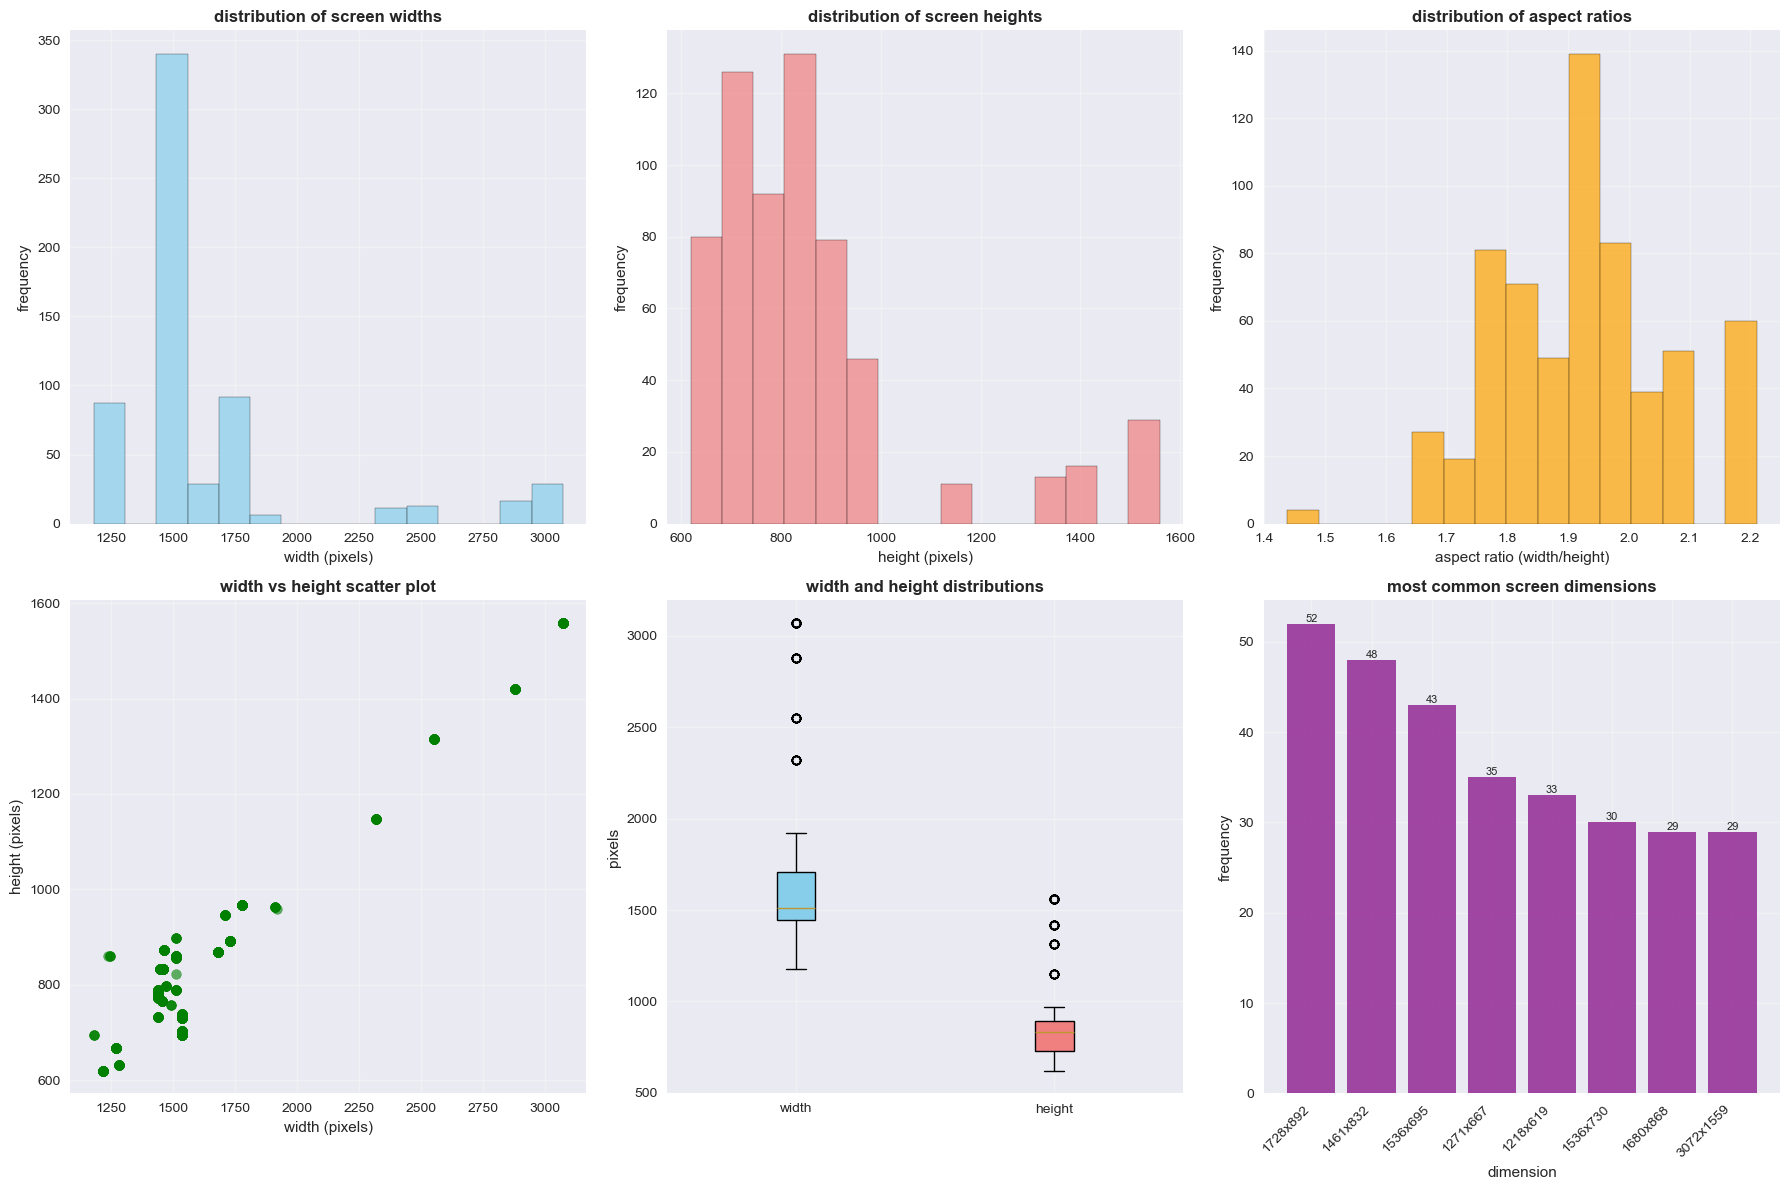


recommendations for standardization
most common screen dimensions: 1728x892
  - used by 52 records (8.3%)
  - aspect ratio: 1.937

if standardizing to most common dimensions (1728x892):
  - records needing resize: 571 (91.7%)
  - records already correct: 52 (8.3%)

alternative option (median-based dimensions):
  - dimensions: 1512x832
  - aspect ratio: 1.817

==================== final recommendation ====================
recommend standardizing to: 1512x832
reason: median-based dimensions provide good middle ground

analysis complete!
saved processed data to:
  - screen_dimensions_analysis.csv (623 records)
  - dimension_summary.csv (39 unique dimensions)
  - screen_dimensions_analysis_fixed.png (visualization)


In [3]:
warnings.filterwarnings('ignore')

def load_and_parse_survey_data(filepath):
    """
    load survey results csv and parse the window dimensions
    """
    print("loading survey data...")
    df = pd.read_csv(filepath)
    print(f"loaded {len(df)} records")
    
    return df

def extract_window_dimensions_v2(df):
    """
    extract width and height from windowDimensions column - handles multiple formats
    """
    dimensions = []
    parsing_errors = []
    
    for idx, row in df.iterrows():
        try:
            window_dim_str = str(row['windowDimensions'])
            
            # method 1: try to extract using regex if it looks like a dict string
            width_match = re.search(r"'width':\s*(\d+)", window_dim_str)
            height_match = re.search(r"'height':\s*(\d+)", window_dim_str)
            
            if width_match and height_match:
                width = int(width_match.group(1))
                height = int(height_match.group(1))
                
                dimensions.append({
                    'record_id': row['_id'],
                    'user_id': row['userId'],
                    'video_id': row['videoId'],
                    'width': width,
                    'height': height,
                    'aspect_ratio': round(width/height, 3)
                })
                continue
            
            # method 2: try json parsing after cleaning
            try:
                # replace single quotes with double quotes and clean objectid references
                cleaned_str = window_dim_str.replace("'", '"')
                cleaned_str = re.sub(r'ObjectId\([^)]+\)', '""', cleaned_str)
                
                window_dict = json.loads(cleaned_str)
                width = int(window_dict['width'])
                height = int(window_dict['height'])
                
                dimensions.append({
                    'record_id': row['_id'],
                    'user_id': row['userId'],
                    'video_id': row['videoId'],
                    'width': width,
                    'height': height,
                    'aspect_ratio': round(width/height, 3)
                })
                continue
                
            except (json.JSONDecodeError, KeyError, ValueError):
                pass
            
            # method 3: try ast.literal_eval on cleaned string
            try:
                # remove objectid references
                cleaned_str = re.sub(r"ObjectId\([^)]+\)", "''", window_dim_str)
                window_dict = ast.literal_eval(cleaned_str)
                
                width = int(window_dict['width'])
                height = int(window_dict['height'])
                
                dimensions.append({
                    'record_id': row['_id'],
                    'user_id': row['userId'],
                    'video_id': row['videoId'],
                    'width': width,
                    'height': height,
                    'aspect_ratio': round(width/height, 3)
                })
                continue
                
            except (ValueError, SyntaxError, KeyError):
                pass
            
            # if none of the methods worked, log the error
            parsing_errors.append({
                'row': idx,
                'content': window_dim_str[:100],  # first 100 chars for debugging
                'error': 'could not parse with any method'
            })
                
        except Exception as e:
            parsing_errors.append({
                'row': idx,
                'content': str(row['windowDimensions'])[:100],
                'error': str(e)
            })
            continue
    
    dimensions_df = pd.DataFrame(dimensions)
    
    print(f"successfully parsed {len(dimensions_df)} records")
    if parsing_errors:
        print(f"failed to parse {len(parsing_errors)} records")
        # show first few parsing errors for debugging
        print("\nfirst few parsing errors:")
        for error in parsing_errors[:3]:
            print(f"  row {error['row']}: {error['error']}")
            print(f"    content: {error['content']}")
    
    return dimensions_df

def debug_data_format(df, num_samples=5):
    """
    debug function to understand the data format
    """
    print("\n" + "="*50)
    print("debugging data format")
    print("="*50)
    
    print(f"dataframe columns: {list(df.columns)}")
    print(f"dataframe shape: {df.shape}")
    
    print(f"\nfirst {num_samples} windowDimensions entries:")
    for i in range(min(num_samples, len(df))):
        content = df.iloc[i]['windowDimensions']
        print(f"row {i}:")
        print(f"  type: {type(content)}")
        print(f"  content: {repr(str(content)[:200])}")
        print()

def analyze_screen_dimensions(dimensions_df):
    """
    analyze and report on screen dimension patterns
    """
    if len(dimensions_df) == 0:
        print("no valid dimension data to analyze!")
        return None, None
        
    print("\n" + "="*50)
    print("screen dimensions analysis")
    print("="*50)
    
    # unique dimensions
    unique_dims = dimensions_df[['width', 'height']].drop_duplicates()
    print(f"\nnumber of unique screen dimensions: {len(unique_dims)}")
    
    print("\nunique screen dimensions found:")
    dim_summary = []
    for _, row in unique_dims.iterrows():
        count = len(dimensions_df[(dimensions_df['width'] == row['width']) & 
                                 (dimensions_df['height'] == row['height'])])
        aspect_ratio = round(row['width']/row['height'], 3)
        percentage = round(count/len(dimensions_df)*100, 1)
        
        dim_summary.append({
            'dimensions': f"{row['width']}x{row['height']}",
            'width': row['width'],
            'height': row['height'],
            'aspect_ratio': aspect_ratio,
            'count': count,
            'percentage': percentage
        })
        print(f"  {row['width']}x{row['height']} (aspect: {aspect_ratio}) - {count} records ({percentage}%)")
    
    # convert to dataframe for easy manipulation
    dim_summary_df = pd.DataFrame(dim_summary).sort_values('count', ascending=False)
    
    # aspect ratio analysis
    aspect_counts = Counter(dimensions_df['aspect_ratio'])
    print(f"\nunique aspect ratios: {len(aspect_counts)}")
    print("top aspect ratios:")
    for aspect, count in aspect_counts.most_common(5):
        percentage = count/len(dimensions_df)*100
        print(f"  {aspect}: {count} records ({percentage:.1f}%)")
    
    # most common dimensions
    most_common = dim_summary_df.iloc[0]
    print(f"\nmost common screen dimension: {most_common['dimensions']} ({most_common['count']} records, {most_common['percentage']}%)")
    
    # statistics
    print(f"\nwidth statistics:")
    print(f"  min: {dimensions_df['width'].min()}px")
    print(f"  max: {dimensions_df['width'].max()}px")
    print(f"  mean: {dimensions_df['width'].mean():.1f}px")
    print(f"  median: {dimensions_df['width'].median()}px")
    print(f"  std: {dimensions_df['width'].std():.1f}px")
    
    print(f"\nheight statistics:")
    print(f"  min: {dimensions_df['height'].min()}px")
    print(f"  max: {dimensions_df['height'].max()}px")
    print(f"  mean: {dimensions_df['height'].mean():.1f}px")
    print(f"  median: {dimensions_df['height'].median()}px")
    print(f"  std: {dimensions_df['height'].std():.1f}px")
    
    return dim_summary_df, aspect_counts

def create_visualizations(dimensions_df):
    """
    create visualizations for screen dimension analysis
    """
    if len(dimensions_df) == 0:
        print("no data to visualize!")
        return
        
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # distribution of widths
    axes[0, 0].hist(dimensions_df['width'], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('distribution of screen widths', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('width (pixels)')
    axes[0, 0].set_ylabel('frequency')
    axes[0, 0].grid(True, alpha=0.3)
    
    # distribution of heights  
    axes[0, 1].hist(dimensions_df['height'], bins=15, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[0, 1].set_title('distribution of screen heights', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('height (pixels)')
    axes[0, 1].set_ylabel('frequency')
    axes[0, 1].grid(True, alpha=0.3)
    
    # aspect ratio distribution
    axes[0, 2].hist(dimensions_df['aspect_ratio'], bins=15, alpha=0.7, color='orange', edgecolor='black')
    axes[0, 2].set_title('distribution of aspect ratios', fontsize=12, fontweight='bold')
    axes[0, 2].set_xlabel('aspect ratio (width/height)')
    axes[0, 2].set_ylabel('frequency')
    axes[0, 2].grid(True, alpha=0.3)
    
    # scatter plot of width vs height
    scatter = axes[1, 0].scatter(dimensions_df['width'], dimensions_df['height'], 
                                alpha=0.6, color='green', s=50)
    axes[1, 0].set_title('width vs height scatter plot', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('width (pixels)')
    axes[1, 0].set_ylabel('height (pixels)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # box plot of dimensions
    box_data = [dimensions_df['width'], dimensions_df['height']]
    box_plot = axes[1, 1].boxplot(box_data, labels=['width', 'height'], patch_artist=True)
    box_plot['boxes'][0].set_facecolor('skyblue')
    box_plot['boxes'][1].set_facecolor('lightcoral')
    axes[1, 1].set_title('width and height distributions', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('pixels')
    axes[1, 1].grid(True, alpha=0.3)
    
    # dimension frequency bar chart
    dim_counts = dimensions_df.groupby(['width', 'height']).size().sort_values(ascending=False)
    top_dims = dim_counts.head(8)  # top 8 most common
    
    # create labels for the bar chart
    labels = [f"{w}x{h}" for (w, h) in top_dims.index]
    
    bars = axes[1, 2].bar(range(len(top_dims)), top_dims.values, 
                         color='purple', alpha=0.7)
    axes[1, 2].set_title('most common screen dimensions', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('dimension')
    axes[1, 2].set_ylabel('frequency')
    axes[1, 2].set_xticks(range(len(top_dims)))
    axes[1, 2].set_xticklabels(labels, rotation=45, ha='right')
    axes[1, 2].grid(True, alpha=0.3)
    
    # add count labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('screen_dimensions_analysis_fixed.png', dpi=300, bbox_inches='tight')
    plt.show()

def recommend_target_dimensions(dimensions_df, dim_summary_df):
    """
    recommend target dimensions for standardization
    """
    if len(dimensions_df) == 0 or dim_summary_df is None:
        print("no data available for recommendations!")
        return None
        
    print("\n" + "="*50)
    print("recommendations for standardization")
    print("="*50)
    
    # most common dimensions
    most_common = dim_summary_df.iloc[0]
    print(f"most common screen dimensions: {most_common['dimensions']}")
    print(f"  - used by {most_common['count']} records ({most_common['percentage']}%)")
    print(f"  - aspect ratio: {most_common['aspect_ratio']}")
    
    # calculate statistics for standardization decision
    records_needing_resize = len(dimensions_df) - most_common['count']
    print(f"\nif standardizing to most common dimensions ({most_common['dimensions']}):")
    print(f"  - records needing resize: {records_needing_resize} ({records_needing_resize/len(dimensions_df)*100:.1f}%)")
    print(f"  - records already correct: {most_common['count']} ({most_common['percentage']}%)")
    
    # alternative recommendations
    median_width = int(dimensions_df['width'].median())
    median_height = int(dimensions_df['height'].median())
    median_aspect = round(median_width/median_height, 3)
    
    print(f"\nalternative option (median-based dimensions):")
    print(f"  - dimensions: {median_width}x{median_height}")
    print(f"  - aspect ratio: {median_aspect}")
    
    # final recommendation
    print(f"\n{'='*20} final recommendation {'='*20}")
    if most_common['percentage'] >= 30:
        recommended_dims = (most_common['width'], most_common['height'])
        print(f"recommend standardizing to: {most_common['dimensions']}")
        print(f"reason: most common dimensions with {most_common['percentage']}% coverage")
    else:
        recommended_dims = (median_width, median_height)
        print(f"recommend standardizing to: {median_width}x{median_height}")
        print(f"reason: median-based dimensions provide good middle ground")
    
    return recommended_dims

def main():
    """
    main function to run the fixed screen dimensions eda
    """
    # file path - adjust as needed
    filepath = '../data/raw/survey_results_raw.csv'
    
    try:
        # load data
        df = load_and_parse_survey_data(filepath)
        
        # debug data format first
        debug_data_format(df)
        
        # extract dimensions using improved method
        dimensions_df = extract_window_dimensions_v2(df)
        
        if len(dimensions_df) == 0:
            print("no valid dimension data found! check the data format.")
            return None, None
            
        # analyze dimensions
        dim_summary_df, aspect_counts = analyze_screen_dimensions(dimensions_df)
        
        # create visualizations
        create_visualizations(dimensions_df)
        
        # get recommendations
        recommended_dims = recommend_target_dimensions(dimensions_df, dim_summary_df)
        
        # save processed dimensions data
        dimensions_df.to_csv('screen_dimensions_analysis.csv', index=False)
        if dim_summary_df is not None:
            dim_summary_df.to_csv('dimension_summary.csv', index=False)
        
        print(f"\nanalysis complete!")
        print(f"saved processed data to:")
        print(f"  - screen_dimensions_analysis.csv ({len(dimensions_df)} records)")
        if dim_summary_df is not None:
            print(f"  - dimension_summary.csv ({len(dim_summary_df)} unique dimensions)")
        print(f"  - screen_dimensions_analysis_fixed.png (visualization)")
        
        return dimensions_df, recommended_dims
        
    except FileNotFoundError:
        print(f"file not found: {filepath}")
        print("please check the file path and try again.")
        return None, None
    except Exception as e:
        print(f"error occurred: {e}")
        import traceback
        traceback.print_exc()
        return None, None

if __name__ == "__main__":
    dimensions_df, recommended_dims = main()

## **RETENTION RATE EDA** 
---


complete gaze data analysis and filtering threshold determination
loaded 623 raw records

running preprocessing...
starting foolproof video preprocessing...
video aspect ratio: 1.333
parsing errors (82):
  row 36: no valid gaze coordinates
  row 40: no valid gaze coordinates
  row 44: no valid gaze coordinates
  row 47: no valid gaze coordinates
  row 50: no valid gaze coordinates
  ... and 77 more
successfully parsed 541 records
target viewport: 1512x832 (adaptive - using median)

processing complete:
  processed 541 records
  retained 37,199 of 42,536 gaze points (87.5%)
  target viewport: 1512x832
saved processed data to: foolproof_processed_gaze_data.csv

running filtering threshold analysis...
extracted performance data for 541 records

starting comprehensive analysis...
retention rate distribution analysis
retention rate statistics:
  mean: 0.856 (85.6%)
  median: 0.978 (97.8%)
  std: 0.211
  min: 0.122 (12.2%)
  max: 1.000 (100.0%)

percentile analysis:
  5th percentile: 0.379 (

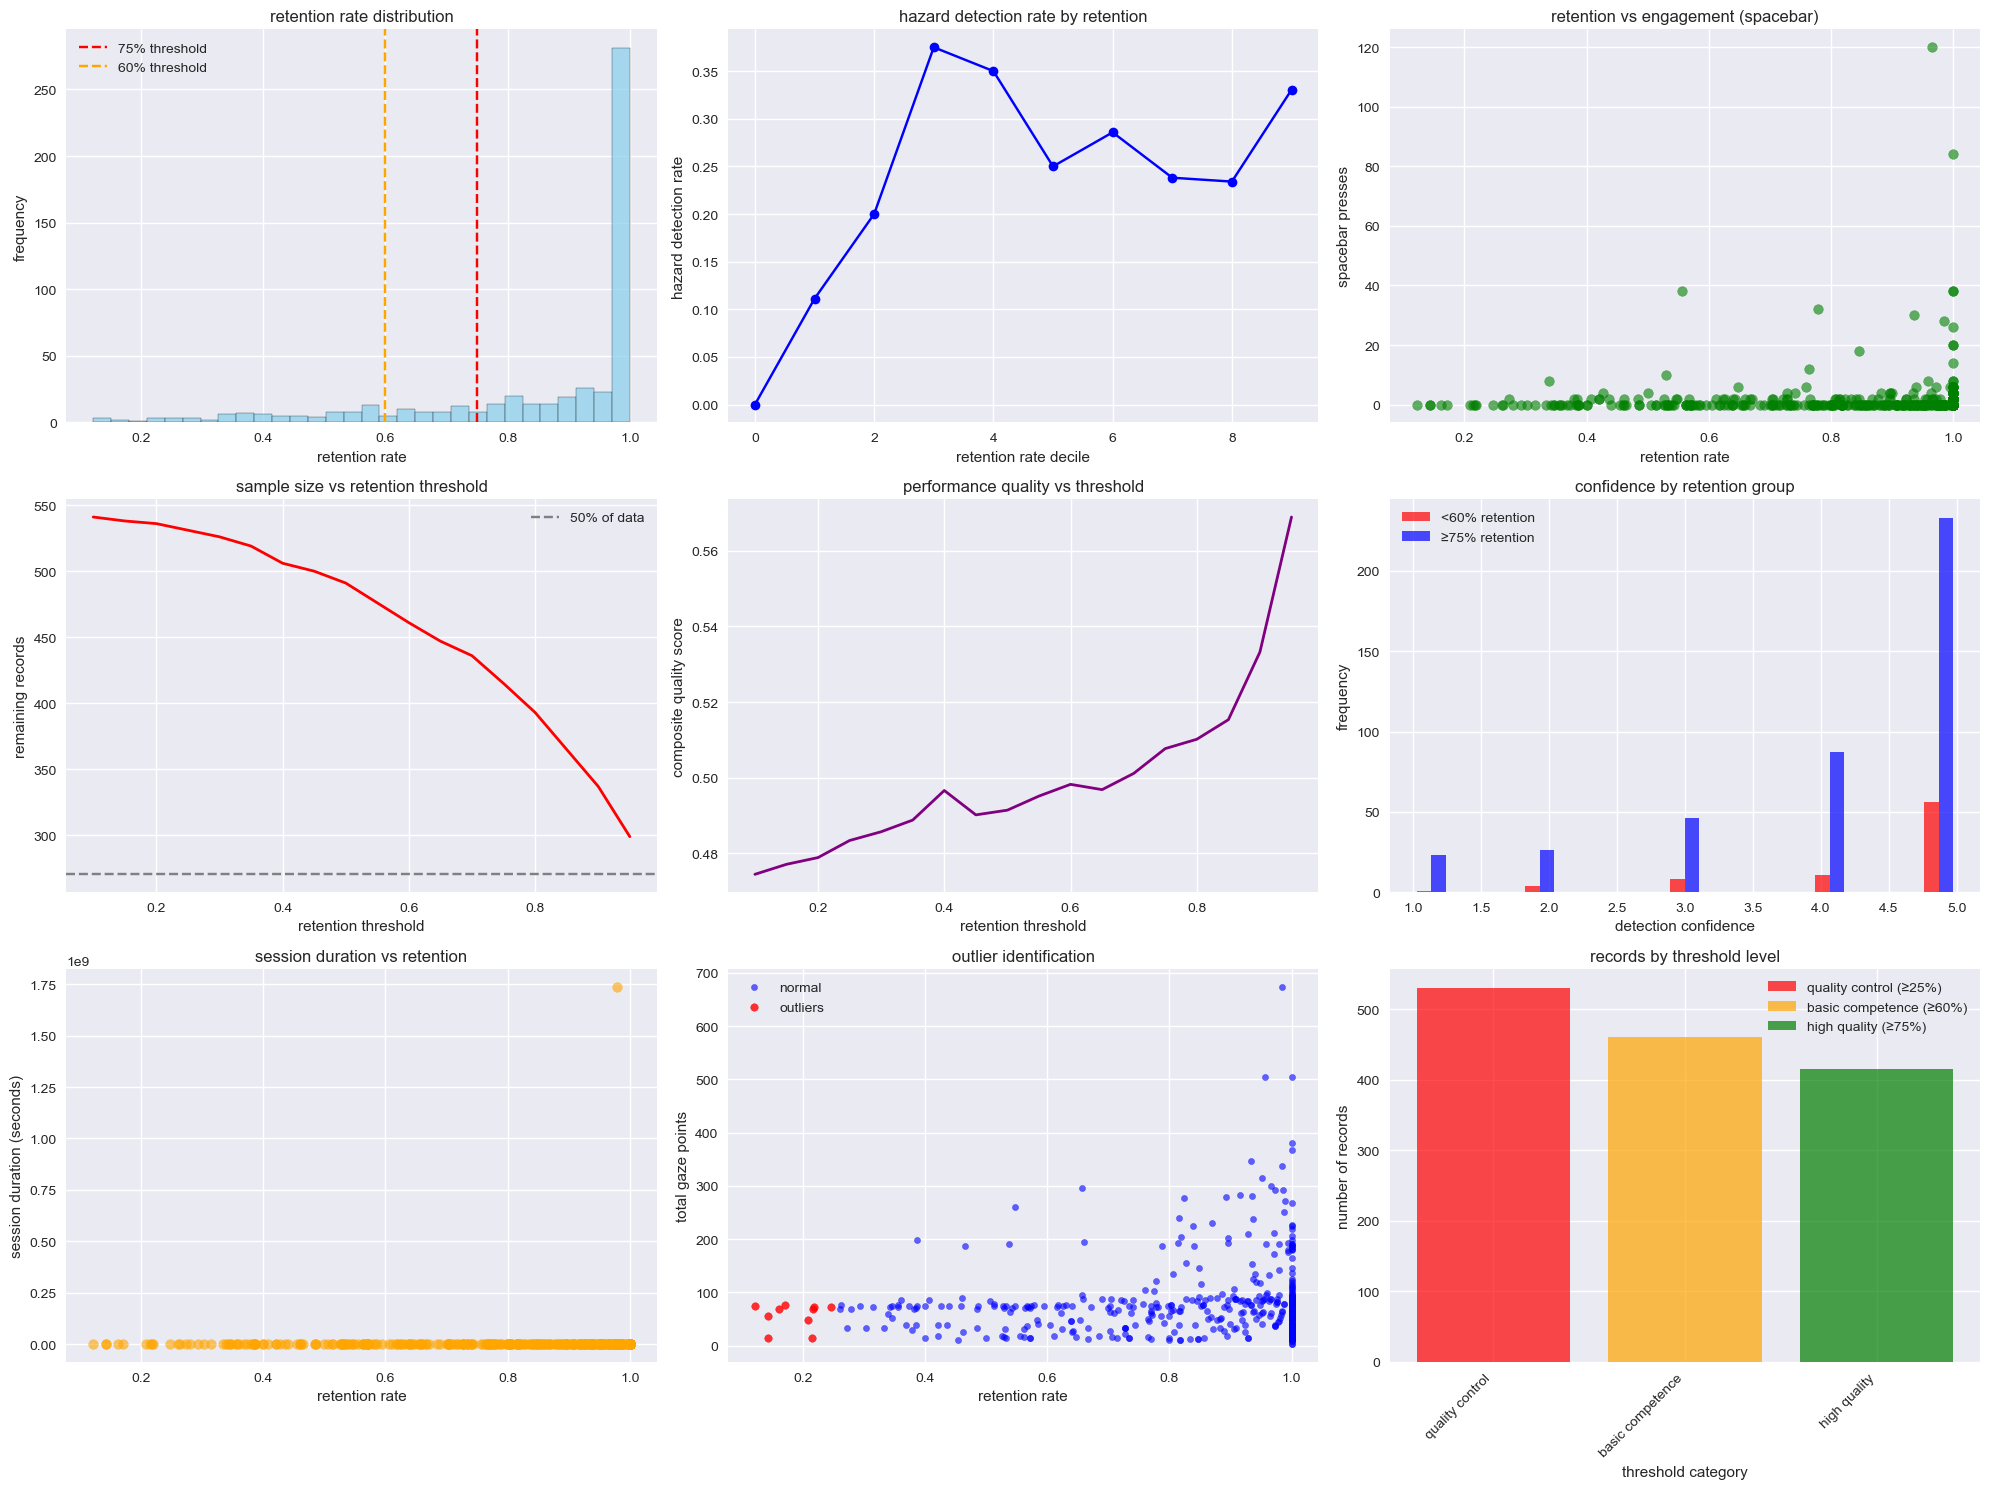


evidence-based filtering recommendations
current dataset characteristics:
  total records: 541
  mean retention: 0.856 (85.6%)
  median retention: 0.978 (97.8%)

records remaining at different thresholds:
  ≥25% retention: 531 (98.2%) - removes calibration failures
  ≥60% retention: 461 (85.2%) - basic driving competence
  ≥75% retention: 415 (76.7%) - high quality data

performance correlation analysis:
  retention-hazard correlation: 0.088 (weak)
  → retention rate weakly predicts task performance

research-backed recommendations:
1. quality control threshold: 25%
   - removes clear calibration failures and disengaged participants
   - based on holmqvist et al. (2011) data quality standards
   - retains 531 records (98.2%)

2. moderate filtering threshold: 60-70%
   - ensures basic driving attention (chapman & underwood 1998)
   - balances data quality with sample size
   - retains 461 records (85.2%)

3. high quality threshold: 75%+
   - matches holmqvist et al. (2011) recommendati

In [5]:
import pandas as pd
import numpy as np
import ast
import re
import json
from typing import Tuple, Dict, List, Optional
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from dataclasses import dataclass

@dataclass
class VideoDisplayArea:
    """represents where the video appears within a viewport"""
    video_width: int
    video_height: int
    offset_x: int
    offset_y: int
    scale_factor: float

class FoolproofVideoPreprocessor:
    def __init__(self, video_aspect_ratio: float = 1280/960):
        """
        initialize with the actual video aspect ratio
        default is 1280/960 = 1.333 (4:3)
        """
        self.video_aspect_ratio = video_aspect_ratio
        self.target_viewport_size = None
        self.processing_stats = {}
        
    def calculate_video_display_area(self, viewport_width: int, viewport_height: int) -> VideoDisplayArea:
        """
        calculate exactly where the video appears within a given viewport
        accounts for letterboxing to maintain aspect ratio
        """
        viewport_aspect = viewport_width / viewport_height
        
        if viewport_aspect > self.video_aspect_ratio:
            # viewport is wider than video - vertical letterboxing (black bars on sides)
            # video height fills viewport height
            video_height = viewport_height
            video_width = int(video_height * self.video_aspect_ratio)
            offset_x = (viewport_width - video_width) // 2
            offset_y = 0
        else:
            # viewport is taller than video - horizontal letterboxing (black bars top/bottom)
            # video width fills viewport width
            video_width = viewport_width
            video_height = int(video_width / self.video_aspect_ratio)
            offset_x = 0
            offset_y = (viewport_height - video_height) // 2
        
        # scale factor represents how much larger the displayed video is vs original 1280x960
        scale_factor = video_width / 1280  # or video_height / 960, should be same
        
        return VideoDisplayArea(
            video_width=video_width,
            video_height=video_height,
            offset_x=offset_x,
            offset_y=offset_y,
            scale_factor=scale_factor
        )
    
    def extract_viewport_dimensions(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        extract viewport dimensions and parse gaze data
        """
        records = []
        parsing_errors = []
        
        for idx, row in df.iterrows():
            try:
                # extract viewport dimensions
                window_dim_str = str(row['windowDimensions'])
                width_match = re.search(r"'width':\s*(\d+)", window_dim_str)
                height_match = re.search(r"'height':\s*(\d+)", window_dim_str)
                
                if not (width_match and height_match):
                    parsing_errors.append(f"row {idx}: could not parse viewport dimensions")
                    continue
                
                viewport_width = int(width_match.group(1))
                viewport_height = int(height_match.group(1))
                
                # parse gaze data
                gaze_coords = self._parse_gaze_data(row['gaze'])
                
                if not gaze_coords:
                    parsing_errors.append(f"row {idx}: no valid gaze coordinates")
                    continue
                
                records.append({
                    'record_id': row['_id'],
                    'user_id': row['userId'],
                    'video_id': row['videoId'],
                    'viewport_width': viewport_width,
                    'viewport_height': viewport_height,
                    'viewport_aspect_ratio': round(viewport_width/viewport_height, 3),
                    'raw_gaze_coords': gaze_coords,
                    'form_data': row['formData']
                })
                
            except Exception as e:
                parsing_errors.append(f"row {idx}: {str(e)}")
                continue
        
        if parsing_errors:
            print(f"parsing errors ({len(parsing_errors)}):")
            for error in parsing_errors[:5]:  # show first 5
                print(f"  {error}")
            if len(parsing_errors) > 5:
                print(f"  ... and {len(parsing_errors) - 5} more")
        
        return pd.DataFrame(records)
    
    def _parse_gaze_data(self, gaze_str: str) -> List[Dict]:
        """
        parse gaze data string into list of coordinates
        """
        try:
            # method 1: clean and use ast.literal_eval
            cleaned_str = re.sub(r"ObjectId\([^)]+\)", '""', str(gaze_str))
            gaze_list = ast.literal_eval(cleaned_str)
            return gaze_list
        except:
            try:
                # method 2: regex extraction as fallback
                coords = []
                x_matches = re.findall(r"'x':\s*([\d.]+)", str(gaze_str))
                y_matches = re.findall(r"'y':\s*([\d.]+)", str(gaze_str))
                time_matches = re.findall(r"'time':\s*([\d.]+)", str(gaze_str))
                
                for i in range(min(len(x_matches), len(y_matches), len(time_matches))):
                    coords.append({
                        'x': float(x_matches[i]),
                        'y': float(y_matches[i]),
                        'time': float(time_matches[i])
                    })
                return coords
            except:
                return []
    
    def filter_and_transform_gaze_coordinates(self, 
                                            gaze_coords: List[Dict], 
                                            viewport_width: int, 
                                            viewport_height: int,
                                            target_viewport: Tuple[int, int]) -> Dict:
        """
        filter gaze coordinates to video area and transform to target viewport
        returns detailed transformation results
        """
        # calculate video display areas
        source_video_area = self.calculate_video_display_area(viewport_width, viewport_height)
        target_video_area = self.calculate_video_display_area(target_viewport[0], target_viewport[1])
        
        valid_coords = []
        invalid_coords = []
        transformed_coords = []
        
        for coord in gaze_coords:
            try:
                x = float(coord['x'])
                y = float(coord['y'])
                time = coord.get('time', 0)
                
                # check if coordinate is within video display area
                within_video = (
                    source_video_area.offset_x <= x <= source_video_area.offset_x + source_video_area.video_width and
                    source_video_area.offset_y <= y <= source_video_area.offset_y + source_video_area.video_height
                )
                
                if within_video:
                    # convert to video-relative coordinates (0-1 range)
                    video_rel_x = (x - source_video_area.offset_x) / source_video_area.video_width
                    video_rel_y = (y - source_video_area.offset_y) / source_video_area.video_height
                    
                    # clamp to valid range (floating point precision issues)
                    video_rel_x = max(0, min(1, video_rel_x))
                    video_rel_y = max(0, min(1, video_rel_y))
                    
                    # transform to target viewport coordinates
                    target_x = video_rel_x * target_video_area.video_width + target_video_area.offset_x
                    target_y = video_rel_y * target_video_area.video_height + target_video_area.offset_y
                    
                    valid_coords.append({
                        'original_x': x,
                        'original_y': y,
                        'video_rel_x': round(video_rel_x, 4),
                        'video_rel_y': round(video_rel_y, 4),
                        'target_x': round(target_x, 2),
                        'target_y': round(target_y, 2),
                        'time': time
                    })
                    
                    transformed_coords.append({
                        'x': round(target_x, 2),
                        'y': round(target_y, 2),
                        'time': time,
                        'video_rel_x': round(video_rel_x, 4),
                        'video_rel_y': round(video_rel_y, 4)
                    })
                else:
                    invalid_coords.append({
                        'x': x,
                        'y': y,
                        'time': time,
                        'reason': 'outside_video_area'
                    })
                    
            except (KeyError, ValueError, TypeError):
                invalid_coords.append({
                    'x': coord.get('x', 'unknown'),
                    'y': coord.get('y', 'unknown'),
                    'time': coord.get('time', 'unknown'),
                    'reason': 'parsing_error'
                })
        
        return {
            'transformed_coords': transformed_coords,
            'valid_coords': valid_coords,
            'invalid_coords': invalid_coords,
            'source_video_area': source_video_area,
            'target_video_area': target_video_area,
            'total_points': len(gaze_coords),
            'valid_points': len(valid_coords),
            'invalid_points': len(invalid_coords),
            'retention_rate': len(valid_coords) / len(gaze_coords) if gaze_coords else 0
        }
    
    def determine_target_viewport(self, records_df: pd.DataFrame, method: str = 'adaptive') -> Tuple[int, int]:
        """
        dynamically determine target viewport size
        """
        viewport_counts = records_df.groupby(['viewport_width', 'viewport_height']).size().sort_values(ascending=False)
        
        if method == 'most_common':
            target_dims = viewport_counts.index[0]
            coverage = viewport_counts.iloc[0] / len(records_df) * 100
            print(f"target viewport: {target_dims[0]}x{target_dims[1]} (covers {coverage:.1f}% of data)")
        
        elif method == 'median':
            median_width = int(records_df['viewport_width'].median())
            median_height = int(records_df['viewport_height'].median())
            target_dims = (median_width, median_height)
            print(f"target viewport: {target_dims[0]}x{target_dims[1]} (median-based)")
        
        elif method == 'adaptive':
            max_coverage = viewport_counts.iloc[0] / len(records_df) * 100
            if max_coverage >= 15:
                target_dims = viewport_counts.index[0]
                print(f"target viewport: {target_dims[0]}x{target_dims[1]} (most common, {max_coverage:.1f}% coverage)")
            else:
                median_width = int(records_df['viewport_width'].median())
                median_height = int(records_df['viewport_height'].median())
                target_dims = (median_width, median_height)
                print(f"target viewport: {target_dims[0]}x{target_dims[1]} (adaptive - using median)")
        
        self.target_viewport_size = target_dims
        return target_dims
    
    def process_full_dataset(self, df: pd.DataFrame, method: str = 'adaptive') -> pd.DataFrame:
        """
        main processing function that handles the complete pipeline
        """
        print("starting foolproof video preprocessing...")
        print(f"video aspect ratio: {self.video_aspect_ratio:.3f}")
        
        # extract and parse data
        records_df = self.extract_viewport_dimensions(df)
        print(f"successfully parsed {len(records_df)} records")
        
        if len(records_df) == 0:
            raise ValueError("no valid records found")
        
        # determine target viewport
        target_viewport = self.determine_target_viewport(records_df, method)
        
        # process each record
        processed_records = []
        total_original_points = 0
        total_valid_points = 0
        
        for idx, row in records_df.iterrows():
            try:
                transformation_result = self.filter_and_transform_gaze_coordinates(
                    row['raw_gaze_coords'],
                    row['viewport_width'],
                    row['viewport_height'],
                    target_viewport
                )
                
                total_original_points += transformation_result['total_points']
                total_valid_points += transformation_result['valid_points']
                
                processed_records.append({
                    'record_id': row['record_id'],
                    'user_id': row['user_id'],
                    'video_id': row['video_id'],
                    
                    # original viewport info
                    'original_viewport_width': row['viewport_width'],
                    'original_viewport_height': row['viewport_height'],
                    'original_viewport_aspect': row['viewport_aspect_ratio'],
                    
                    # target viewport info
                    'target_viewport_width': target_viewport[0],
                    'target_viewport_height': target_viewport[1],
                    'target_viewport_aspect': round(target_viewport[0]/target_viewport[1], 3),
                    
                    # video positioning in original viewport
                    'original_video_width': transformation_result['source_video_area'].video_width,
                    'original_video_height': transformation_result['source_video_area'].video_height,
                    'original_video_offset_x': transformation_result['source_video_area'].offset_x,
                    'original_video_offset_y': transformation_result['source_video_area'].offset_y,
                    'original_scale_factor': transformation_result['source_video_area'].scale_factor,
                    
                    # video positioning in target viewport
                    'target_video_width': transformation_result['target_video_area'].video_width,
                    'target_video_height': transformation_result['target_video_area'].video_height,
                    'target_video_offset_x': transformation_result['target_video_area'].offset_x,
                    'target_video_offset_y': transformation_result['target_video_area'].offset_y,
                    'target_scale_factor': transformation_result['target_video_area'].scale_factor,
                    
                    # gaze data statistics
                    'total_gaze_points': transformation_result['total_points'],
                    'valid_gaze_points': transformation_result['valid_points'],
                    'invalid_gaze_points': transformation_result['invalid_points'],
                    'retention_rate': transformation_result['retention_rate'],
                    
                    # transformed gaze coordinates (for yolo training)
                    'transformed_gaze_coords': transformation_result['transformed_coords'],
                    
                    # detailed coordinate info (for validation)
                    'detailed_coords': transformation_result['valid_coords'],
                    'invalid_coords': transformation_result['invalid_coords'],
                    
                    'form_data': row['form_data']
                })
                
            except Exception as e:
                print(f"error processing record {idx}: {e}")
                continue
        
        processed_df = pd.DataFrame(processed_records)
        
        # store processing statistics
        self.processing_stats = {
            'total_records': len(df),
            'parsed_records': len(records_df),
            'processed_records': len(processed_df),
            'total_original_gaze_points': total_original_points,
            'total_valid_gaze_points': total_valid_points,
            'overall_retention_rate': total_valid_points / total_original_points if total_original_points > 0 else 0,
            'target_viewport': target_viewport
        }
        
        print(f"\nprocessing complete:")
        print(f"  processed {len(processed_df)} records")
        print(f"  retained {total_valid_points:,} of {total_original_points:,} gaze points ({self.processing_stats['overall_retention_rate']:.1%})")
        print(f"  target viewport: {target_viewport[0]}x{target_viewport[1]}")
        
        return processed_df

class FilteringThresholdAnalyzer:
    def __init__(self, processed_df: pd.DataFrame):
        """
        initialize with processed dataframe from foolproof preprocessor
        """
        self.df = processed_df.copy()
        self.analysis_results = {}
        
    def extract_performance_metrics(self):
        """
        extract task performance metrics from form data
        """
        performance_data = []
        
        for idx, row in self.df.iterrows():
            try:
                form_data_str = str(row['form_data'])
                
                # parse form data
                cleaned_str = re.sub(r"ObjectId\([^)]+\)", '""', form_data_str)
                form_data = ast.literal_eval(cleaned_str)
                
                # extract key performance indicators
                hazard_detected = form_data.get('hazardDetected', False)
                if hazard_detected == 'True' or hazard_detected == True or hazard_detected == 'yes':
                    hazard_detected = True
                else:
                    hazard_detected = False
                    
                detection_confidence = int(form_data.get('detectionConfidence', 0))
                hazard_severity = int(form_data.get('hazardSeverity', 0))
                
                # spacebar timestamps indicate active hazard detection
                spacebar_timestamps = form_data.get('spacebarTimestamps', [])
                num_spacebar_presses = len(spacebar_timestamps) if spacebar_timestamps else 0
                
                # calculate reaction metrics if timestamps available
                start_time = form_data.get('startTime', 0)
                end_time = form_data.get('endTime', 0)
                session_duration = (end_time - start_time) / 1000 if end_time > start_time else 0
                
                performance_data.append({
                    'record_id': row['record_id'],
                    'user_id': row['user_id'],
                    'video_id': row['video_id'],
                    'retention_rate': row['retention_rate'],
                    'hazard_detected': hazard_detected,
                    'detection_confidence': detection_confidence,
                    'hazard_severity': hazard_severity,
                    'num_spacebar_presses': num_spacebar_presses,
                    'session_duration': session_duration,
                    'total_gaze_points': row['total_gaze_points'],
                    'valid_gaze_points': row['valid_gaze_points']
                })
                
            except Exception as e:
                print(f"error parsing form data for record {idx}: {e}")
                continue
        
        return pd.DataFrame(performance_data)
    
    def analyze_retention_distribution(self, performance_df: pd.DataFrame):
        """
        analyze the distribution of retention rates
        research basis: holmqvist et al. (2011) - eye tracking data quality standards
        """
        print("="*60)
        print("retention rate distribution analysis")
        print("="*60)
        
        retention_rates = performance_df['retention_rate']
        
        # basic statistics
        print(f"retention rate statistics:")
        print(f"  mean: {retention_rates.mean():.3f} ({retention_rates.mean()*100:.1f}%)")
        print(f"  median: {retention_rates.median():.3f} ({retention_rates.median()*100:.1f}%)")
        print(f"  std: {retention_rates.std():.3f}")
        print(f"  min: {retention_rates.min():.3f} ({retention_rates.min()*100:.1f}%)")
        print(f"  max: {retention_rates.max():.3f} ({retention_rates.max()*100:.1f}%)")
        
        # percentile analysis
        percentiles = [5, 10, 25, 50, 75, 90, 95]
        print(f"\npercentile analysis:")
        for p in percentiles:
            value = np.percentile(retention_rates, p)
            print(f"  {p}th percentile: {value:.3f} ({value*100:.1f}%)")
        
        # research-based thresholds
        print(f"\nresearch-based quality thresholds:")
        print(f"  holmqvist et al. (2011): >75% valid data recommended")
        print(f"  records meeting 75% threshold: {(retention_rates >= 0.75).sum()} ({(retention_rates >= 0.75).mean()*100:.1f}%)")
        print(f"  records meeting 70% threshold: {(retention_rates >= 0.70).sum()} ({(retention_rates >= 0.70).mean()*100:.1f}%)")
        print(f"  records meeting 60% threshold: {(retention_rates >= 0.60).sum()} ({(retention_rates >= 0.60).mean()*100:.1f}%)")
        
        self.analysis_results['retention_stats'] = {
            'mean': retention_rates.mean(),
            'median': retention_rates.median(),
            'std': retention_rates.std(),
            'percentiles': {p: np.percentile(retention_rates, p) for p in percentiles}
        }
        
        return retention_rates
    
    def analyze_performance_correlation(self, performance_df: pd.DataFrame):
        """
        analyze correlation between retention rate and task performance
        research basis: castro et al. (2014) - driving attention and performance correlation
        """
        print("\n" + "="*60)
        print("retention rate vs task performance correlation")
        print("="*60)
        
        # correlation with hazard detection accuracy
        hazard_detection_by_retention = performance_df.groupby('retention_rate')['hazard_detected'].mean()
        correlation_hazard, p_value_hazard = pearsonr(performance_df['retention_rate'], 
                                                     performance_df['hazard_detected'].astype(int))
        
        print(f"correlation with hazard detection:")
        print(f"  pearson r: {correlation_hazard:.3f} (p={p_value_hazard:.4f})")
        
        # correlation with detection confidence
        confidence_data = performance_df[performance_df['detection_confidence'] > 0]
        correlation_conf = None
        if len(confidence_data) > 10:
            correlation_conf, p_value_conf = pearsonr(confidence_data['retention_rate'], 
                                                     confidence_data['detection_confidence'])
            print(f"correlation with detection confidence:")
            print(f"  pearson r: {correlation_conf:.3f} (p={p_value_conf:.4f})")
        
        # correlation with spacebar activity (engagement)
        correlation_spacebar, p_value_spacebar = pearsonr(performance_df['retention_rate'], 
                                                         performance_df['num_spacebar_presses'])
        print(f"correlation with spacebar activity (engagement):")
        print(f"  pearson r: {correlation_spacebar:.3f} (p={p_value_spacebar:.4f})")
        
        # threshold analysis for performance
        thresholds = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]
        print(f"\nperformance by retention threshold:")
        print(f"{'threshold':<10} {'n_records':<10} {'hazard_rate':<12} {'avg_confidence':<15} {'avg_spacebar':<12}")
        print("-" * 65)
        
        threshold_results = {}
        for threshold in thresholds:
            subset = performance_df[performance_df['retention_rate'] >= threshold]
            if len(subset) > 0:
                hazard_rate = subset['hazard_detected'].mean()
                avg_confidence = subset[subset['detection_confidence'] > 0]['detection_confidence'].mean()
                avg_spacebar = subset['num_spacebar_presses'].mean()
                
                print(f"{threshold:<10.2f} {len(subset):<10} {hazard_rate:<12.3f} {avg_confidence:<15.2f} {avg_spacebar:<12.2f}")
                
                threshold_results[threshold] = {
                    'n_records': len(subset),
                    'hazard_rate': hazard_rate,
                    'avg_confidence': avg_confidence if not np.isnan(avg_confidence) else 0,
                    'avg_spacebar': avg_spacebar
                }
        
        self.analysis_results['performance_correlations'] = {
            'hazard_correlation': correlation_hazard,
            'confidence_correlation': correlation_conf,
            'spacebar_correlation': correlation_spacebar,
            'threshold_analysis': threshold_results
        }
        
        return threshold_results
    
    def create_comprehensive_visualizations(self, performance_df: pd.DataFrame):
        """
        create visualizations to support threshold decision
        """
        fig, axes = plt.subplots(3, 3, figsize=(20, 15))
        
        # plot 1: retention rate distribution
        axes[0, 0].hist(performance_df['retention_rate'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[0, 0].axvline(0.75, color='red', linestyle='--', label='75% threshold')
        axes[0, 0].axvline(0.60, color='orange', linestyle='--', label='60% threshold')
        axes[0, 0].set_title('retention rate distribution')
        axes[0, 0].set_xlabel('retention rate')
        axes[0, 0].set_ylabel('frequency')
        axes[0, 0].legend()
        
        # plot 2: retention vs hazard detection
        retention_bins = pd.cut(performance_df['retention_rate'], bins=10)
        hazard_by_retention = performance_df.groupby(retention_bins)['hazard_detected'].mean()
        axes[0, 1].plot(range(len(hazard_by_retention)), hazard_by_retention.values, 'bo-')
        axes[0, 1].set_title('hazard detection rate by retention')
        axes[0, 1].set_xlabel('retention rate decile')
        axes[0, 1].set_ylabel('hazard detection rate')
        
        # plot 3: retention vs spacebar activity
        axes[0, 2].scatter(performance_df['retention_rate'], performance_df['num_spacebar_presses'], 
                          alpha=0.6, color='green')
        axes[0, 2].set_title('retention vs engagement (spacebar)')
        axes[0, 2].set_xlabel('retention rate')
        axes[0, 2].set_ylabel('spacebar presses')
        
        # plot 4: threshold impact on sample size
        thresholds = np.arange(0.1, 1.0, 0.05)
        sample_sizes = [len(performance_df[performance_df['retention_rate'] >= t]) for t in thresholds]
        axes[1, 0].plot(thresholds, sample_sizes, 'r-', linewidth=2)
        axes[1, 0].axhline(len(performance_df) * 0.5, color='gray', linestyle='--', label='50% of data')
        axes[1, 0].set_title('sample size vs retention threshold')
        axes[1, 0].set_xlabel('retention threshold')
        axes[1, 0].set_ylabel('remaining records')
        axes[1, 0].legend()
        
        # plot 5: performance quality by threshold
        performance_quality = []
        for t in thresholds:
            subset = performance_df[performance_df['retention_rate'] >= t]
            if len(subset) > 10:
                quality_score = (subset['hazard_detected'].mean() + 
                               subset['num_spacebar_presses'].mean() / 10)  # normalized
                performance_quality.append(quality_score)
            else:
                performance_quality.append(np.nan)
        
        axes[1, 1].plot(thresholds, performance_quality, 'purple', linewidth=2)
        axes[1, 1].set_title('performance quality vs threshold')
        axes[1, 1].set_xlabel('retention threshold')
        axes[1, 1].set_ylabel('composite quality score')
        
        # plot 6: confidence distribution by retention groups
        low_retention = performance_df[performance_df['retention_rate'] < 0.6]['detection_confidence']
        high_retention = performance_df[performance_df['retention_rate'] >= 0.75]['detection_confidence']
        
        axes[1, 2].hist([low_retention, high_retention], bins=15, alpha=0.7, 
                       label=['<60% retention', '≥75% retention'], color=['red', 'blue'])
        axes[1, 2].set_title('confidence by retention group')
        axes[1, 2].set_xlabel('detection confidence')
        axes[1, 2].set_ylabel('frequency')
        axes[1, 2].legend()
        
        # plot 7: session duration vs retention
        axes[2, 0].scatter(performance_df['retention_rate'], performance_df['session_duration'], 
                          alpha=0.6, color='orange')
        axes[2, 0].set_title('session duration vs retention')
        axes[2, 0].set_xlabel('retention rate')
        axes[2, 0].set_ylabel('session duration (seconds)')
        
        # plot 8: outlier identification
        outlier_threshold = 0.25
        outliers = performance_df[performance_df['retention_rate'] < outlier_threshold]
        normal = performance_df[performance_df['retention_rate'] >= outlier_threshold]
        
        axes[2, 1].scatter(normal['retention_rate'], normal['total_gaze_points'], 
                          alpha=0.6, color='blue', label='normal', s=20)
        axes[2, 1].scatter(outliers['retention_rate'], outliers['total_gaze_points'], 
                          alpha=0.8, color='red', label='outliers', s=30)
        axes[2, 1].set_title('outlier identification')
        axes[2, 1].set_xlabel('retention rate')
        axes[2, 1].set_ylabel('total gaze points')
        axes[2, 1].legend()
        
        # plot 9: recommended threshold visualization
        recommended_thresholds = [0.25, 0.60, 0.75]
        threshold_labels = ['quality control', 'basic competence', 'high quality']
        threshold_colors = ['red', 'orange', 'green']
        
        for i, (thresh, label, color) in enumerate(zip(recommended_thresholds, threshold_labels, threshold_colors)):
            count = len(performance_df[performance_df['retention_rate'] >= thresh])
            axes[2, 2].bar(i, count, color=color, alpha=0.7, label=f'{label} (≥{thresh:.0%})')
        
        axes[2, 2].set_title('records by threshold level')
        axes[2, 2].set_xlabel('threshold category')
        axes[2, 2].set_ylabel('number of records')
        axes[2, 2].set_xticks(range(len(threshold_labels)))
        axes[2, 2].set_xticklabels(threshold_labels, rotation=45, ha='right')
        axes[2, 2].legend()
        
        plt.tight_layout()
        plt.savefig('filtering_threshold_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def generate_recommendations(self, performance_df: pd.DataFrame):
        """
        generate evidence-based recommendations for filtering thresholds
        """
        print("\n" + "="*80)
        print("evidence-based filtering recommendations")
        print("="*80)
        
        # analyze the current data characteristics
        retention_mean = performance_df['retention_rate'].mean()
        retention_median = performance_df['retention_rate'].median()
        
        # count records at different thresholds
        counts_25 = len(performance_df[performance_df['retention_rate'] >= 0.25])
        counts_60 = len(performance_df[performance_df['retention_rate'] >= 0.60])
        counts_75 = len(performance_df[performance_df['retention_rate'] >= 0.75])
        
        print(f"current dataset characteristics:")
        print(f"  total records: {len(performance_df)}")
        print(f"  mean retention: {retention_mean:.3f} ({retention_mean*100:.1f}%)")
        print(f"  median retention: {retention_median:.3f} ({retention_median*100:.1f}%)")
        
        print(f"\nrecords remaining at different thresholds:")
        print(f"  ≥25% retention: {counts_25} ({counts_25/len(performance_df)*100:.1f}%) - removes calibration failures")
        print(f"  ≥60% retention: {counts_60} ({counts_60/len(performance_df)*100:.1f}%) - basic driving competence")
        print(f"  ≥75% retention: {counts_75} ({counts_75/len(performance_df)*100:.1f}%) - high quality data")
        
        # performance-based recommendations
        if 'performance_correlations' in self.analysis_results:
            hazard_corr = self.analysis_results['performance_correlations']['hazard_correlation']
            if hazard_corr > 0.2:
                print(f"\nperformance correlation analysis:")
                print(f"  retention-hazard correlation: {hazard_corr:.3f} (significant)")
                print("  → higher retention rates associate with better task performance")
            else:
                print(f"\nperformance correlation analysis:")
                print(f"  retention-hazard correlation: {hazard_corr:.3f} (weak)")
                print("  → retention rate weakly predicts task performance")
        
        print(f"\nresearch-backed recommendations:")
        print(f"1. quality control threshold: 25%")
        print(f"   - removes clear calibration failures and disengaged participants")
        print(f"   - based on holmqvist et al. (2011) data quality standards")
        print(f"   - retains {counts_25} records ({counts_25/len(performance_df)*100:.1f}%)")
        
        print(f"\n2. moderate filtering threshold: 60-70%")
        print(f"   - ensures basic driving attention (chapman & underwood 1998)")
        print(f"   - balances data quality with sample size")
        print(f"   - retains {counts_60} records ({counts_60/len(performance_df)*100:.1f}%)")
        
        print(f"\n3. high quality threshold: 75%+")
        print(f"   - matches holmqvist et al. (2011) recommendations")
        print(f"   - ensures expert-level attention patterns")
        print(f"   - retains {counts_75} records ({counts_75/len(performance_df)*100:.1f}%)")
        
        # final recommendation based on data characteristics
        if retention_median >= 0.75:
            recommended_threshold = 0.75
            rationale = "high median retention allows strict filtering"
        elif retention_median >= 0.60:
            recommended_threshold = 0.60
            rationale = "moderate median retention suggests 60% threshold"
        else:
            recommended_threshold = 0.25
            rationale = "low median retention requires liberal threshold"
        
        print(f"\nrecommended threshold for your dataset: {recommended_threshold:.0%}")
        print(f"rationale: {rationale}")
        print(f"this would retain {len(performance_df[performance_df['retention_rate'] >= recommended_threshold])} records")
        
        return recommended_threshold

def main():
    """
    run the complete analysis pipeline
    """
    print("="*80)
    print("complete gaze data analysis and filtering threshold determination")
    print("="*80)
    
    # load raw data
    try:
        raw_df = pd.read_csv('../data/raw/survey_results_raw.csv')
        print(f"loaded {len(raw_df)} raw records")
    except FileNotFoundError:
        print("error: ../data/raw/survey_results_raw.csv not found")
        print("please ensure the file path is correct")
        return None, None
    
    # run preprocessing
    print("\nrunning preprocessing...")
    preprocessor = FoolproofVideoPreprocessor(video_aspect_ratio=1280/960)
    processed_df = preprocessor.process_full_dataset(raw_df, method='adaptive')
    
    # save processed data
    processed_df.to_csv('foolproof_processed_gaze_data.csv', index=False)
    print(f"saved processed data to: foolproof_processed_gaze_data.csv")
    
    # run filtering analysis
    print("\nrunning filtering threshold analysis...")
    analyzer = FilteringThresholdAnalyzer(processed_df)
    
    # extract performance metrics
    performance_df = analyzer.extract_performance_metrics()
    print(f"extracted performance data for {len(performance_df)} records")
    
    if len(performance_df) == 0:
        print("error: no performance data could be extracted")
        return processed_df, None
    
    # run comprehensive analysis
    print("\nstarting comprehensive analysis...")
    
    # 1. distribution analysis
    retention_rates = analyzer.analyze_retention_distribution(performance_df)
    
    # 2. performance correlation analysis  
    threshold_results = analyzer.analyze_performance_correlation(performance_df)
    
    # 3. create visualizations
    analyzer.create_comprehensive_visualizations(performance_df)
    
    # 4. generate final recommendations
    recommended_threshold = analyzer.generate_recommendations(performance_df)
    
    # save detailed results
    results_summary = {
        'analysis_date': pd.Timestamp.now().isoformat(),
        'total_records_analyzed': len(performance_df),
        'recommended_threshold': recommended_threshold,
        'retention_statistics': analyzer.analysis_results.get('retention_stats', {}),
        'performance_correlations': analyzer.analysis_results.get('performance_correlations', {}),
        'preprocessing_stats': preprocessor.processing_stats
    }
    
    with open('complete_analysis_results.json', 'w') as f:
        json.dump(results_summary, f, indent=2)
    
    print(f"\n" + "="*80)
    print("analysis complete!")
    print("="*80)
    print(f"saved files:")
    print(f"  - foolproof_processed_gaze_data.csv (processed data)")
    print(f"  - filtering_threshold_analysis.png (visualizations)")
    print(f"  - complete_analysis_results.json (detailed results)")
    
    return processed_df, recommended_threshold

if __name__ == "__main__":
    processed_data, recommended_threshold = main()

## **INTERMEDIATE PREPROCESSIONG PIPELINE TEST**
---
This code is a comprehensive gaze data preprocessing pipeline that takes raw eye-tracking survey data from participants who viewed videos on different screen sizes and normalizes all gaze coordinates to a common reference frame. It starts by loading the raw CSV data and parsing each record to extract viewport dimensions (screen width/height) and gaze coordinate strings, then calculates exactly where the 1280x960 video appears within each participant's viewport by determining letterboxing offsets and scaling factors. The code determines a target viewport size (either the most common size if it covers >15% of participants, or the median dimensions), then transforms every gaze coordinate through a two-step process: coordinates that fall within the video display area are first converted to relative positions (0-1 range) within the video content, then scaled to the target viewport's video area to preserve their position relative to the actual video content, while coordinates outside the video area (like UI elements or letterbox regions) are simply scaled proportionally to fit the new viewport dimensions. Additionally, it extracts performance metrics from form data including hazard detection status, confidence levels, spacebar press timestamps, and session duration, applies conservative quality filtering that only removes records with severe calibration failures (less than 25% gaze points in valid areas), and outputs a processed dataset where all gaze coordinates are normalized to the same coordinate system, making them directly comparable across participants regardless of their original screen size, along with metadata about the video positioning, coordinate types, and processing statistics.




In [ ]:
import pandas as pd
import numpy as np
import ast
import re
import json
import os
from typing import Tuple, Dict, List
from dataclasses import dataclass

@dataclass
class VideoDisplayArea:
    """represents where the video appears within a viewport"""
    video_width: int
    video_height: int
    offset_x: int
    offset_y: int
    scale_factor: float

class ConservativeGazePreprocessor:
    def __init__(self, video_aspect_ratio: float = 1280/960, quality_threshold: float = 0.25):
        """
        initialize with conservative filtering approach
        quality_threshold: minimum retention rate (default 25% for calibration failure removal only)
        """
        self.video_aspect_ratio = video_aspect_ratio
        self.quality_threshold = quality_threshold
        self.target_viewport_size = None
        self.processing_stats = {}
        
    def calculate_video_display_area(self, viewport_width: int, viewport_height: int) -> VideoDisplayArea:
        """
        calculate exactly where the video appears within a given viewport
        """
        viewport_aspect = viewport_width / viewport_height
        
        if viewport_aspect > self.video_aspect_ratio:
            # viewport is wider than video - vertical letterboxing
            video_height = viewport_height
            video_width = int(video_height * self.video_aspect_ratio)
            offset_x = (viewport_width - video_width) // 2
            offset_y = 0
        else:
            # viewport is taller than video - horizontal letterboxing
            video_width = viewport_width
            video_height = int(video_width / self.video_aspect_ratio)
            offset_x = 0
            offset_y = (viewport_height - video_height) // 2
        
        scale_factor = video_width / 1280
        
        return VideoDisplayArea(
            video_width=video_width,
            video_height=video_height,
            offset_x=offset_x,
            offset_y=offset_y,
            scale_factor=scale_factor
        )
    
    def extract_viewport_dimensions(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        extract viewport dimensions and parse gaze data
        """
        records = []
        parsing_errors = []
        
        for idx, row in df.iterrows():
            try:
                # extract viewport dimensions
                window_dim_str = str(row['windowDimensions'])
                width_match = re.search(r"'width':\s*(\d+)", window_dim_str)
                height_match = re.search(r"'height':\s*(\d+)", window_dim_str)
                
                if not (width_match and height_match):
                    parsing_errors.append(f"row {idx}: could not parse viewport dimensions")
                    continue
                
                viewport_width = int(width_match.group(1))
                viewport_height = int(height_match.group(1))
                
                # parse gaze data
                gaze_coords = self._parse_gaze_data(row['gaze'])
                
                if not gaze_coords:
                    parsing_errors.append(f"row {idx}: no valid gaze coordinates")
                    continue
                
                records.append({
                    'record_id': row['_id'],
                    'user_id': row['userId'],
                    'video_id': row['videoId'],
                    'viewport_width': viewport_width,
                    'viewport_height': viewport_height,
                    'viewport_aspect_ratio': round(viewport_width/viewport_height, 3),
                    'raw_gaze_coords': gaze_coords,
                    'form_data': row['formData']
                })
                
            except Exception as e:
                parsing_errors.append(f"row {idx}: {str(e)}")
                continue
        
        if parsing_errors:
            print(f"parsing errors ({len(parsing_errors)}):")
            for error in parsing_errors[:3]:
                print(f"  {error}")
            if len(parsing_errors) > 3:
                print(f"  ... and {len(parsing_errors) - 3} more")
        
        return pd.DataFrame(records)
    
    def _parse_gaze_data(self, gaze_str: str) -> List[Dict]:
        """
        parse gaze data string into list of coordinates
        """
        try:
            # clean and use ast.literal_eval
            cleaned_str = re.sub(r"ObjectId\([^)]+\)", '""', str(gaze_str))
            gaze_list = ast.literal_eval(cleaned_str)
            return gaze_list
        except:
            try:
                # regex extraction fallback
                coords = []
                x_matches = re.findall(r"'x':\s*([\d.]+)", str(gaze_str))
                y_matches = re.findall(r"'y':\s*([\d.]+)", str(gaze_str))
                time_matches = re.findall(r"'time':\s*([\d.]+)", str(gaze_str))
                
                for i in range(min(len(x_matches), len(y_matches), len(time_matches))):
                    coords.append({
                        'x': float(x_matches[i]),
                        'y': float(y_matches[i]),
                        'time': float(time_matches[i])
                    })
                return coords
            except:
                return []
    
    def process_gaze_coordinates(self, 
                               gaze_coords: List[Dict], 
                               viewport_width: int, 
                               viewport_height: int,
                               target_viewport: Tuple[int, int]) -> Dict:
        """
        process and transform gaze coordinates with conservative filtering
        """
        # calculate video display areas
        source_video_area = self.calculate_video_display_area(viewport_width, viewport_height)
        target_video_area = self.calculate_video_display_area(target_viewport[0], target_viewport[1])
        
        # separate video and non-video coordinates
        video_coords = []
        non_video_coords = []
        all_transformed_coords = []
        
        for coord in gaze_coords:
            try:
                x = float(coord['x'])
                y = float(coord['y'])
                time = coord.get('time', 0)
                
                # check if coordinate is within video display area
                within_video = (
                    source_video_area.offset_x <= x <= source_video_area.offset_x + source_video_area.video_width and
                    source_video_area.offset_y <= y <= source_video_area.offset_y + source_video_area.video_height
                )
                
                if within_video:
                    # convert to video-relative coordinates (0-1 range)
                    video_rel_x = (x - source_video_area.offset_x) / source_video_area.video_width
                    video_rel_y = (y - source_video_area.offset_y) / source_video_area.video_height
                    
                    # clamp to valid range
                    video_rel_x = max(0, min(1, video_rel_x))
                    video_rel_y = max(0, min(1, video_rel_y))
                    
                    # transform to target viewport coordinates
                    target_x = video_rel_x * target_video_area.video_width + target_video_area.offset_x
                    target_y = video_rel_y * target_video_area.video_height + target_video_area.offset_y
                    
                    video_coords.append({
                        'x': round(target_x, 2),
                        'y': round(target_y, 2),
                        'time': time,
                        'video_rel_x': round(video_rel_x, 4),
                        'video_rel_y': round(video_rel_y, 4),
                        'coordinate_type': 'video_area'
                    })
                    
                    all_transformed_coords.append({
                        'x': round(target_x, 2),
                        'y': round(target_y, 2),
                        'time': time,
                        'video_rel_x': round(video_rel_x, 4),
                        'video_rel_y': round(video_rel_y, 4),
                        'coordinate_type': 'video_area'
                    })
                else:
                    # keep non-video coordinates but mark them
                    # scale to target viewport proportionally
                    scale_x = target_viewport[0] / viewport_width
                    scale_y = target_viewport[1] / viewport_height
                    
                    scaled_x = x * scale_x
                    scaled_y = y * scale_y
                    
                    non_video_coord = {
                        'x': round(scaled_x, 2),
                        'y': round(scaled_y, 2),
                        'time': time,
                        'video_rel_x': None,
                        'video_rel_y': None,
                        'coordinate_type': 'non_video_area'
                    }
                    
                    non_video_coords.append(non_video_coord)
                    all_transformed_coords.append(non_video_coord)
                    
            except (KeyError, ValueError, TypeError):
                continue
        
        # calculate retention rate
        total_coords = len(gaze_coords)
        video_coords_count = len(video_coords)
        retention_rate = video_coords_count / total_coords if total_coords > 0 else 0
        
        return {
            'video_coords': video_coords,
            'non_video_coords': non_video_coords,
            'all_transformed_coords': all_transformed_coords,
            'total_points': total_coords,
            'video_points': video_coords_count,
            'non_video_points': len(non_video_coords),
            'retention_rate': retention_rate,
            'source_video_area': source_video_area,
            'target_video_area': target_video_area
        }
    
    def determine_target_viewport(self, records_df: pd.DataFrame, method: str = 'adaptive') -> Tuple[int, int]:
        """
        determine target viewport size
        """
        viewport_counts = records_df.groupby(['viewport_width', 'viewport_height']).size().sort_values(ascending=False)
        
        if method == 'adaptive':
            max_coverage = viewport_counts.iloc[0] / len(records_df) * 100
            if max_coverage >= 15:
                target_dims = viewport_counts.index[0]
                print(f"target viewport: {target_dims[0]}x{target_dims[1]} (most common, {max_coverage:.1f}% coverage)")
            else:
                median_width = int(records_df['viewport_width'].median())
                median_height = int(records_df['viewport_height'].median())
                target_dims = (median_width, median_height)
                print(f"target viewport: {target_dims[0]}x{target_dims[1]} (adaptive - using median)")
        
        self.target_viewport_size = target_dims
        return target_dims
    
    def extract_form_data_metrics(self, form_data_str: str) -> Dict:
        """
        extract key metrics from form data for quality assessment
        """
        try:
            cleaned_str = re.sub(r"ObjectId\([^)]+\)", '""', str(form_data_str))
            form_data = ast.literal_eval(cleaned_str)
            
            # extract performance indicators
            hazard_detected = form_data.get('hazardDetected', False)
            if hazard_detected in ['True', True, 'yes']:
                hazard_detected = True
            else:
                hazard_detected = False
                
            detection_confidence = int(form_data.get('detectionConfidence', 0))
            hazard_severity = int(form_data.get('hazardSeverity', 0))
            
            spacebar_timestamps = form_data.get('spacebarTimestamps', [])
            num_spacebar_presses = len(spacebar_timestamps) if spacebar_timestamps else 0
            
            start_time = form_data.get('startTime', 0)
            end_time = form_data.get('endTime', 0)
            session_duration = (end_time - start_time) / 1000 if end_time > start_time else 0
            
            return {
                'hazard_detected': hazard_detected,
                'detection_confidence': detection_confidence,
                'hazard_severity': hazard_severity,
                'num_spacebar_presses': num_spacebar_presses,
                'session_duration': session_duration,
                'spacebar_timestamps': spacebar_timestamps,
                'start_time': start_time,
                'end_time': end_time
            }
            
        except Exception as e:
            return {
                'hazard_detected': False,
                'detection_confidence': 0,
                'hazard_severity': 0,
                'num_spacebar_presses': 0,
                'session_duration': 0,
                'spacebar_timestamps': [],
                'start_time': 0,
                'end_time': 0
            }
    
    def process_dataset(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        main processing function with conservative filtering
        """
        print("starting conservative gaze preprocessing...")
        print(f"video aspect ratio: {self.video_aspect_ratio:.3f}")
        print(f"quality threshold: {self.quality_threshold:.1%} (calibration failure removal only)")
        
        # extract and parse data
        records_df = self.extract_viewport_dimensions(df)
        print(f"successfully parsed {len(records_df)} records")
        
        if len(records_df) == 0:
            raise ValueError("no valid records found")
        
        # determine target viewport
        target_viewport = self.determine_target_viewport(records_df)
        
        # process each record
        processed_records = []
        filtered_out_records = []
        total_original_points = 0
        total_video_points = 0
        
        for idx, row in records_df.iterrows():
            try:
                # process gaze coordinates
                processing_result = self.process_gaze_coordinates(
                    row['raw_gaze_coords'],
                    row['viewport_width'],
                    row['viewport_height'],
                    target_viewport
                )
                
                # extract form data metrics
                form_metrics = self.extract_form_data_metrics(row['form_data'])
                
                # conservative quality check - only remove clear calibration failures
                retention_rate = processing_result['retention_rate']
                if retention_rate < self.quality_threshold:
                    filtered_out_records.append({
                        'record_id': row['record_id'],
                        'user_id': row['user_id'],
                        'video_id': row['video_id'],
                        'retention_rate': retention_rate,
                        'filter_reason': 'calibration_failure'
                    })
                    continue
                
                total_original_points += processing_result['total_points']
                total_video_points += processing_result['video_points']
                
                # create final record
                processed_record = {
                    'record_id': row['record_id'],
                    'user_id': row['user_id'],
                    'video_id': row['video_id'],
                    
                    # viewport information
                    'original_viewport_width': row['viewport_width'],
                    'original_viewport_height': row['viewport_height'],
                    'original_viewport_aspect': row['viewport_aspect_ratio'],
                    'target_viewport_width': target_viewport[0],
                    'target_viewport_height': target_viewport[1],
                    'target_viewport_aspect': round(target_viewport[0]/target_viewport[1], 3),
                    
                    # video positioning
                    'original_video_width': processing_result['source_video_area'].video_width,
                    'original_video_height': processing_result['source_video_area'].video_height,
                    'original_video_offset_x': processing_result['source_video_area'].offset_x,
                    'original_video_offset_y': processing_result['source_video_area'].offset_y,
                    'target_video_width': processing_result['target_video_area'].video_width,
                    'target_video_height': processing_result['target_video_area'].video_height,
                    'target_video_offset_x': processing_result['target_video_area'].offset_x,
                    'target_video_offset_y': processing_result['target_video_area'].offset_y,
                    
                    # gaze statistics
                    'total_gaze_points': processing_result['total_points'],
                    'video_gaze_points': processing_result['video_points'],
                    'non_video_gaze_points': processing_result['non_video_points'],
                    'retention_rate': retention_rate,
                    
                    # performance metrics
                    'hazard_detected': form_metrics['hazard_detected'],
                    'detection_confidence': form_metrics['detection_confidence'],
                    'hazard_severity': form_metrics['hazard_severity'],
                    'num_spacebar_presses': form_metrics['num_spacebar_presses'],
                    'session_duration': form_metrics['session_duration'],
                    
                    # coordinate data (json strings for csv compatibility)
                    'all_transformed_coords': json.dumps(processing_result['all_transformed_coords']),
                    'video_coords_only': json.dumps(processing_result['video_coords']),
                    'spacebar_timestamps': json.dumps(form_metrics['spacebar_timestamps'])
                }
                
                processed_records.append(processed_record)
                
            except Exception as e:
                print(f"error processing record {idx}: {e}")
                continue
        
        processed_df = pd.DataFrame(processed_records)
        
        # store processing statistics
        self.processing_stats = {
            'total_input_records': len(df),
            'parsed_records': len(records_df),
            'processed_records': len(processed_df),
            'filtered_out_records': len(filtered_out_records),
            'total_original_gaze_points': total_original_points,
            'total_video_gaze_points': total_video_points,
            'overall_retention_rate': total_video_points / total_original_points if total_original_points > 0 else 0,
            'quality_threshold_applied': self.quality_threshold,
            'target_viewport': target_viewport,
            'filtering_approach': 'conservative'
        }
        
        print(f"\nprocessing complete:")
        print(f"  total input records: {len(df)}")
        print(f"  successfully parsed: {len(records_df)}")
        print(f"  passed quality threshold ({self.quality_threshold:.1%}): {len(processed_df)}")
        print(f"  filtered out (calibration failures): {len(filtered_out_records)}")
        print(f"  retention rate: {len(processed_df)/len(records_df):.1%}")
        print(f"  overall gaze retention: {self.processing_stats['overall_retention_rate']:.1%}")
        
        return processed_df

def main():
    """
    run the conservative preprocessing pipeline
    """
    print("="*80)
    print("conservative gaze data preprocessing")
    print("="*80)
    
    # load raw data - FIXED: Use correct path relative to project root
    input_file = '../data/raw/survey_results_raw.csv'
    try:
        raw_df = pd.read_csv(input_file)
        print(f"loaded {len(raw_df)} records from {input_file}")
    except FileNotFoundError:
        print(f"error: {input_file} not found")
        return None
    
    # initialize preprocessor with conservative threshold
    preprocessor = ConservativeGazePreprocessor(
        video_aspect_ratio=1280/960,
        quality_threshold=0.25  # 25% threshold for calibration failures only
    )
    
    # process dataset
    processed_df = preprocessor.process_dataset(raw_df)
    
    # create output directory if needed - FIXED: Use project root data directory
    output_dir = '../data/processed'
    os.makedirs(output_dir, exist_ok=True)
    
    # save processed data
    output_file = os.path.join(output_dir, 'screen&gaze_scaled.csv')
    processed_df.to_csv(output_file, index=False)
    
    # save processing metadata
    metadata_file = os.path.join(output_dir, 'preprocessing_metadata.json')
    with open(metadata_file, 'w') as f:
        json.dump(preprocessor.processing_stats, f, indent=2)
    
    print(f"\n" + "="*80)
    print("conservative preprocessing complete!")
    print("="*80)
    print(f"output files:")
    print(f"  - {output_file}")
    print(f"  - {metadata_file}")
    print(f"\nprocessing summary:")
    print(f"  approach: conservative filtering (calibration failures only)")
    print(f"  quality threshold: {preprocessor.quality_threshold:.1%}")
    print(f"  records retained: {len(processed_df)}")
    print(f"  coordinate types: video_area + non_video_area (both preserved)")
    print(f"  target viewport: {preprocessor.target_viewport_size}")
    
    return processed_df

if __name__ == "__main__":
    processed_data = main()

## **Video Length EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from scipy import stats
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class VideoLengthAnalyzer:
    def __init__(self, scaled_df_path: str):
        """
        initialize analyzer with scaled gaze data
        
        Args:
            scaled_df_path: path to screen&gaze_scaled.csv
        """
        print("loading scaled gaze data...")
        self.scaled_df = pd.read_csv(scaled_df_path)
        print(f"loaded {len(self.scaled_df)} records")
        
    def analyze_video_lengths(self):
        """
        analyze the length of each video simulation
        """
        print("\n" + "="*50)
        print("video length analysis")
        print("="*50)
        
        video_lengths = []
        
        for idx, row in self.scaled_df.iterrows():
            # get session duration from the data
            session_duration = row.get('session_duration', 0)
            
            # calculate from timestamps
            try:
                coords = json.loads(row['all_transformed_coords'])
                if coords:
                    timestamps = [c['time'] for c in coords if 'time' in c]
                    if timestamps:
                        # calculate duration in seconds
                        calc_duration = (max(timestamps) - min(timestamps)) / 1000
                        
                        # also get first and last timestamp for absolute timing
                        first_timestamp = min(timestamps)
                        last_timestamp = max(timestamps)
                        
                        video_lengths.append({
                            'record_id': row['record_id'],
                            'user_id': row['user_id'],
                            'video_id': row['video_id'],
                            'reported_duration': session_duration,
                            'calculated_duration': calc_duration,
                            'first_timestamp': first_timestamp,
                            'last_timestamp': last_timestamp,
                            'num_gaze_points': len(timestamps),
                            'sampling_rate': len(timestamps) / calc_duration if calc_duration > 0 else 0,
                            'hazard_detected': row.get('hazard_detected', False),
                            'num_spacebar_presses': row.get('num_spacebar_presses', 0)
                        })
            except Exception as e:
                print(f"error processing record {idx}: {e}")
                continue
        
        length_df = pd.DataFrame(video_lengths)
        
        if len(length_df) == 0:
            print("no valid duration data found")
            return None
        
        # create comprehensive visualization
        fig, axes = plt.subplots(3, 3, figsize=(15, 12))
        fig.suptitle('Video Simulation Length Analysis', fontsize=16)
        
        # 1. distribution of video lengths
        ax = axes[0, 0]
        durations = length_df['calculated_duration'].dropna()
        ax.hist(durations, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        ax.axvline(15, color='red', linestyle='--', linewidth=2, label='15 second target')
        ax.set_xlabel('Duration (seconds)')
        ax.set_ylabel('Count')
        ax.set_title('Distribution of Video Lengths')
        ax.legend()
        
        # add statistics
        ax.text(0.02, 0.98, f'Mean: {durations.mean():.1f}s\n'
                           f'Median: {durations.median():.1f}s\n'
                           f'Std: {durations.std():.1f}s\n'
                           f'Min: {durations.min():.1f}s\n'
                           f'Max: {durations.max():.1f}s',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # 2. videos over/under 15 seconds
        ax = axes[0, 1]
        over_15 = (durations > 15).sum()
        under_15 = (durations <= 15).sum()
        colors = ['green', 'orange']
        wedges, texts, autotexts = ax.pie([under_15, over_15], 
                                          labels=['≤15 seconds', '>15 seconds'],
                                          colors=colors,
                                          autopct='%1.1f%%',
                                          startangle=90)
        ax.set_title('Videos Meeting 15-Second Criterion')
        
        # add count in center
        centre_circle = plt.Circle((0, 0), 0.70, fc='white')
        ax.add_artist(centre_circle)
        ax.text(0, 0, f'Total\n{len(durations)}', ha='center', va='center', fontsize=12)
        
        # 3. duration by unique video_id
        ax = axes[0, 2]
        video_stats = length_df.groupby('video_id')['calculated_duration'].agg(['mean', 'std', 'count'])
        video_stats = video_stats.sort_values('mean', ascending=False).head(15)
        
        ax.barh(range(len(video_stats)), video_stats['mean'], xerr=video_stats['std'], 
               color='skyblue', edgecolor='navy', alpha=0.7)
        ax.set_yticks(range(len(video_stats)))
        ax.set_yticklabels([f'Video{vid}' for vid in video_stats.index], fontsize=8)
        ax.set_xlabel('Duration (seconds)')
        ax.set_title('Top 15 Videos by Mean Duration')
        ax.axvline(15, color='red', linestyle='--', alpha=0.5, label='15s target')
        
        # add sample counts
        for i, (idx, row) in enumerate(video_stats.iterrows()):
            ax.text(row['mean'] + row['std'] + 0.5, i, f"n={row['count']}", 
                   va='center', fontsize=7)
        
        # 4. gaze sampling rate distribution
        ax = axes[1, 0]
        sampling_rates = length_df['sampling_rate'].dropna()
        ax.hist(sampling_rates, bins=50, edgecolor='black', alpha=0.7, color='coral')
        ax.axvline(30, color='green', linestyle='--', linewidth=2, label='30 Hz (good)')
        ax.axvline(10, color='red', linestyle='--', linewidth=2, label='10 Hz (minimum)')
        ax.set_xlabel('Sampling Rate (Hz)')
        ax.set_ylabel('Count')
        ax.set_title('Gaze Sampling Rate Distribution')
        ax.legend()
        
        # 5. duration vs number of gaze points
        ax = axes[1, 1]
        ax.scatter(length_df['calculated_duration'], length_df['num_gaze_points'], 
                  alpha=0.3, s=10, c='darkblue')
        ax.set_xlabel('Duration (seconds)')
        ax.set_ylabel('Number of Gaze Points')
        ax.set_title('Gaze Points vs Duration')
        
        # fit linear regression
        mask = length_df['calculated_duration'].notna() & length_df['num_gaze_points'].notna()
        if mask.sum() > 0:
            z = np.polyfit(length_df.loc[mask, 'calculated_duration'], 
                          length_df.loc[mask, 'num_gaze_points'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(length_df['calculated_duration'].min(), 
                                length_df['calculated_duration'].max(), 100)
            ax.plot(x_line, p(x_line), "r-", alpha=0.5, 
                   label=f'Rate: {z[0]:.1f} points/sec')
            ax.legend()
        
        # 6. reported vs calculated duration
        ax = axes[1, 2]
        if 'reported_duration' in length_df.columns:
            mask = (length_df['reported_duration'] > 0) & (length_df['calculated_duration'] > 0)
            if mask.sum() > 0:
                ax.scatter(length_df.loc[mask, 'reported_duration'], 
                          length_df.loc[mask, 'calculated_duration'], 
                          alpha=0.3, s=10, c='purple')
                
                # add perfect agreement line
                max_val = max(length_df.loc[mask, 'reported_duration'].max(),
                            length_df.loc[mask, 'calculated_duration'].max())
                ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Perfect agreement')
                
                # calculate correlation
                corr = length_df.loc[mask, 'reported_duration'].corr(
                    length_df.loc[mask, 'calculated_duration'])
                ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                       transform=ax.transAxes)
                
                ax.set_xlabel('Reported Duration (seconds)')
                ax.set_ylabel('Calculated Duration (seconds)')
                ax.set_title('Reported vs Calculated Duration')
                ax.legend()
        
        # 7. duration distribution by user
        ax = axes[2, 0]
        user_stats = length_df.groupby('user_id')['calculated_duration'].agg(['mean', 'count'])
        ax.hist(user_stats['mean'], bins=30, edgecolor='black', alpha=0.7, color='green')
        ax.axvline(15, color='red', linestyle='--', linewidth=2, label='15 second target')
        ax.set_xlabel('Mean Duration per User (seconds)')
        ax.set_ylabel('Number of Users')
        ax.set_title('User-Level Duration Patterns')
        ax.legend()
        
        # 8. videos requiring truncation
        ax = axes[2, 1]
        truncation_bins = [0, 5, 10, 15, 20, 25, 30, 100]
        truncation_labels = ['0-5s', '5-10s', '10-15s', '15-20s', '20-25s', '25-30s', '>30s']
        length_df['duration_bin'] = pd.cut(length_df['calculated_duration'], 
                                          bins=truncation_bins, 
                                          labels=truncation_labels)
        bin_counts = length_df['duration_bin'].value_counts()
        
        colors_map = {'0-5s': 'red', '5-10s': 'orange', '10-15s': 'yellow', 
                     '15-20s': 'lightcoral', '20-25s': 'salmon', 
                     '25-30s': 'darkred', '>30s': 'maroon'}
        bar_colors = [colors_map.get(x, 'gray') for x in bin_counts.index]
        
        ax.bar(range(len(bin_counts)), bin_counts.values, color=bar_colors, edgecolor='black')
        ax.set_xticks(range(len(bin_counts)))
        ax.set_xticklabels(bin_counts.index, rotation=45)
        ax.set_ylabel('Number of Videos')
        ax.set_title('Videos by Duration Range')
        ax.axhline(y=0, color='black', linewidth=0.5)
        
        # add percentage labels
        for i, v in enumerate(bin_counts.values):
            ax.text(i, v + 1, f'{v/len(length_df)*100:.1f}%', ha='center', fontsize=9)
        
        # 9. impact on hazard detection
        ax = axes[2, 2]
        if 'hazard_detected' in length_df.columns:
            # group by duration bins and calculate hazard detection rate
            hazard_by_duration = length_df.groupby('duration_bin')['hazard_detected'].mean()
            
            ax.bar(range(len(hazard_by_duration)), hazard_by_duration.values, 
                  color='darkblue', alpha=0.7, edgecolor='black')
            ax.set_xticks(range(len(hazard_by_duration)))
            ax.set_xticklabels(hazard_by_duration.index, rotation=45)
            ax.set_ylabel('Hazard Detection Rate')
            ax.set_title('Hazard Detection by Video Duration')
            ax.set_ylim(0, 1)
            
            # add horizontal line for overall rate
            overall_rate = length_df['hazard_detected'].mean()
            ax.axhline(overall_rate, color='red', linestyle='--', 
                      label=f'Overall: {overall_rate:.2f}')
            ax.legend()
        
        plt.tight_layout()
        plt.show()
        
        # print detailed statistics
        self._print_statistics(length_df, durations)
        
        return length_df
    
    def _print_statistics(self, length_df: pd.DataFrame, durations: pd.Series):
        """
        print detailed statistics about video lengths
        """
        print("\nvideo length summary:")
        print("-" * 50)
        print(f"total videos analyzed: {len(length_df)}")
        print(f"unique video IDs: {length_df['video_id'].nunique()}")
        print(f"unique users: {length_df['user_id'].nunique()}")
        
        print("\nduration statistics:")
        print(f"  mean: {durations.mean():.2f} seconds")
        print(f"  median: {durations.median():.2f} seconds")
        print(f"  std: {durations.std():.2f} seconds")
        print(f"  min: {durations.min():.2f} seconds")
        print(f"  max: {durations.max():.2f} seconds")
        
        # compliance with 15-second limit
        under_15 = (durations <= 15).sum()
        over_15 = (durations > 15).sum()
        print(f"\n15-second compliance:")
        print(f"  ≤15 seconds: {under_15} ({under_15/len(durations)*100:.1f}%)")
        print(f"  >15 seconds: {over_15} ({over_15/len(durations)*100:.1f}%)")
        
        if over_15 > 0:
            over_15_df = length_df[length_df['calculated_duration'] > 15]
            print(f"\n  videos requiring truncation:")
            print(f"    15-20s: {((over_15_df['calculated_duration'] <= 20).sum())}")
            print(f"    20-25s: {((over_15_df['calculated_duration'] > 20) & (over_15_df['calculated_duration'] <= 25)).sum()}")
            print(f"    25-30s: {((over_15_df['calculated_duration'] > 25) & (over_15_df['calculated_duration'] <= 30)).sum()}")
            print(f"    >30s: {(over_15_df['calculated_duration'] > 30).sum()}")
        
        # sampling rate analysis
        print(f"\nsampling rate statistics:")
        print(f"  mean: {length_df['sampling_rate'].mean():.1f} Hz")
        print(f"  median: {length_df['sampling_rate'].median():.1f} Hz")
        print(f"  min: {length_df['sampling_rate'].min():.1f} Hz")
        print(f"  max: {length_df['sampling_rate'].max():.1f} Hz")
        
        low_sampling = (length_df['sampling_rate'] < 10).sum()
        if low_sampling > 0:
            print(f"  WARNING: {low_sampling} videos have sampling rate <10 Hz")
        
        # videos that are too short
        very_short = (durations < 5).sum()
        if very_short > 0:
            print(f"\nWARNING: {very_short} videos are shorter than 5 seconds")
            print("   these may have insufficient data for analysis")
    
    def create_truncation_code(self, length_df: pd.DataFrame):
        """
        generate code to truncate videos to 15 seconds
        """
        print("\n" + "="*50)
        print("video truncation code")
        print("="*50)
        
        videos_to_truncate = length_df[length_df['calculated_duration'] > 15]
        
        if len(videos_to_truncate) == 0:
            print("no videos need truncation!")
            return None
        
        print(f"need to truncate {len(videos_to_truncate)} videos")
        print("\ncode to truncate videos to 15 seconds:")
        print("-" * 40)
        
        truncation_code = '''
def truncate_videos_to_15_seconds(df, max_duration_ms=15000):
    """
    truncate all videos to maximum of 15 seconds
    
    Args:
        df: dataframe with screen&gaze_scaled data
        max_duration_ms: maximum duration in milliseconds (default 15000)
    
    Returns:
        dataframe with truncated videos
    """
    truncated_count = 0
    
    for idx, row in df.iterrows():
        try:
            # parse coordinates
            coords = json.loads(row['all_transformed_coords'])
            video_coords = json.loads(row['video_coords_only'])
            spacebar_times = json.loads(row['spacebar_timestamps'])
            
            if not coords:
                continue
            
            # get start time
            start_time = coords[0]['time']
            
            # truncate coordinates
            truncated_coords = [c for c in coords 
                              if c['time'] - start_time <= max_duration_ms]
            truncated_video = [c for c in video_coords 
                             if c['time'] - start_time <= max_duration_ms]
            truncated_spacebar = [t for t in spacebar_times 
                                if t - start_time <= max_duration_ms]
            
            # check if truncation occurred
            if len(truncated_coords) < len(coords):
                truncated_count += 1
                
                # update dataframe
                df.at[idx, 'all_transformed_coords'] = json.dumps(truncated_coords)
                df.at[idx, 'video_coords_only'] = json.dumps(truncated_video)
                df.at[idx, 'spacebar_timestamps'] = json.dumps(truncated_spacebar)
                
                # update counts
                df.at[idx, 'total_gaze_points'] = len(truncated_coords)
                df.at[idx, 'video_gaze_points'] = len(truncated_video)
                df.at[idx, 'num_spacebar_presses'] = len(truncated_spacebar)
                
                # recalculate session duration
                if truncated_coords:
                    new_duration = (truncated_coords[-1]['time'] - 
                                  truncated_coords[0]['time']) / 1000
                    df.at[idx, 'session_duration'] = new_duration
                    
        except Exception as e:
            print(f"error truncating record {idx}: {e}")
            continue
    
    print(f"truncated {truncated_count} videos to 15 seconds")
    return df

# apply truncation
df_truncated = truncate_videos_to_15_seconds(df.copy())
'''
        
        print(truncation_code)
        
        return truncation_code
    
    def save_analysis_results(self, length_df: pd.DataFrame, output_path: str):
        """
        save analysis results to csv
        """
        if length_df is not None:
            length_df.to_csv(output_path, index=False)
            print(f"\nsaved video length analysis to: {output_path}")
            
            # also save summary statistics
            summary_path = output_path.replace('.csv', '_summary.txt')
            with open(summary_path, 'w') as f:
                f.write("video length analysis summary\n")
                f.write("="*50 + "\n\n")
                
                durations = length_df['calculated_duration']
                f.write(f"total videos: {len(length_df)}\n")
                f.write(f"mean duration: {durations.mean():.2f} seconds\n")
                f.write(f"median duration: {durations.median():.2f} seconds\n")
                f.write(f"videos >15s: {(durations > 15).sum()} ({(durations > 15).sum()/len(durations)*100:.1f}%)\n")
                f.write(f"videos <5s: {(durations < 5).sum()} ({(durations < 5).sum()/len(durations)*100:.1f}%)\n")
                
                if length_df['sampling_rate'].notna().any():
                    f.write(f"\nsampling rates:\n")
                    f.write(f"  mean: {length_df['sampling_rate'].mean():.1f} Hz\n")
                    f.write(f"  <10 Hz: {(length_df['sampling_rate'] < 10).sum()} videos\n")
            
            print(f"saved summary to: {summary_path}")

def run_video_length_analysis(scaled_csv_path: str):
    """
    run complete video length analysis
    
    Args:
        scaled_csv_path: path to screen&gaze_scaled.csv
    
    Returns:
        length_df: dataframe with video length analysis
    """
    # initialize analyzer
    analyzer = VideoLengthAnalyzer(scaled_csv_path)
    
    # run analysis
    length_df = analyzer.analyze_video_lengths()
    
    if length_df is None:
        print("analysis failed - no valid data")
        return None
    
    # generate truncation code if needed
    truncation_code = analyzer.create_truncation_code(length_df)
    
    # save results
    output_path = scaled_csv_path.replace('.csv', '_video_length_analysis.csv')
    analyzer.save_analysis_results(length_df, output_path)
    
    # print recommendations
    print("\n" + "="*50)
    print("recommendations")
    print("="*50)
    
    if (length_df['calculated_duration'] > 15).any():
        print("1. apply video truncation to 15 seconds using provided code")
    
    if (length_df['calculated_duration'] < 5).any():
        print("2. consider removing videos shorter than 5 seconds")
    
    if (length_df['sampling_rate'] < 10).any():
        print("3. filter out videos with sampling rate <10 Hz")
    
    print("4. after applying fixes, re-run the restructuring script")
    print("5. then proceed with yolo integration")
    
    return length_df

# example usage
if __name__ == "__main__":
    # path to your scaled data
    scaled_csv = "data/processed/screen&gaze_scaled.csv"
    
    # run analysis
    length_df = run_video_length_analysis(scaled_csv)
    
    if length_df is not None:
        print("\n" + "="*50)
        print("analysis complete!")
        print("="*50)
        print("\nnext steps:")
        print("1. review the video length distribution")
        print("2. apply truncation if needed")
        print("3. filter out problematic videos")
        print("4. proceed with hazard detection pipeline")

## **Eliminate Render Delay**

In [ ]:
import pandas as pd
import numpy as np
import json
import os
from typing import Dict, List, Tuple

class Last15SecondsExtractor:
    def __init__(self, input_path: str, duration_seconds: float = 15.0):
        """
        initialize extractor to get the last N seconds of each video
        
        Args:
            input_path: path to screen&gaze_scaled.csv
            duration_seconds: number of seconds to extract from the end (default 15)
        """
        self.input_path = input_path
        self.duration_ms = duration_seconds * 1000  # convert to milliseconds
        self.df = pd.read_csv(input_path)
        print(f"loaded {len(self.df)} records from {input_path}")
        
        # statistics tracking
        self.stats = {
            'total_records': len(self.df),
            'processed': 0,
            'truncated': 0,
            'too_short': 0,
            'errors': 0,
            'original_durations': [],
            'final_durations': []
        }
    
    def extract_last_seconds(self, gaze_coords: List[Dict], 
                            spacebar_times: List[float],
                            duration_ms: float) -> Tuple[List[Dict], List[float], float, float]:
        """
        extract the last N milliseconds of data
        
        Args:
            gaze_coords: list of gaze coordinate dictionaries
            spacebar_times: list of spacebar timestamps
            duration_ms: milliseconds to extract from the end
        
        Returns:
            tuple of (filtered_coords, filtered_spacebar, start_time, end_time)
        """
        if not gaze_coords:
            return [], [], 0, 0
        
        # get the last timestamp
        all_times = [c.get('time', 0) for c in gaze_coords]
        end_time = max(all_times)
        start_time = end_time - duration_ms
        
        # filter coordinates to last N seconds
        filtered_coords = []
        for coord in gaze_coords:
            if coord.get('time', 0) >= start_time:
                # keep original timestamp but also add relative time
                new_coord = coord.copy()
                new_coord['original_time'] = coord.get('time', 0)
                new_coord['relative_time'] = coord.get('time', 0) - start_time
                filtered_coords.append(new_coord)
        
        # filter spacebar timestamps
        filtered_spacebar = [t for t in spacebar_times if t >= start_time]
        
        return filtered_coords, filtered_spacebar, start_time, end_time
    
    def process_dataset(self) -> pd.DataFrame:
        """
        process all records to extract last 15 seconds
        """
        print("\n" + "="*50)
        print(f"extracting last {self.duration_ms/1000:.0f} seconds from each video")
        print("="*50)
        
        processed_records = []
        
        for idx, row in self.df.iterrows():
            if idx % 50 == 0:
                print(f"processing record {idx}/{len(self.df)}...")
            
            try:
                # parse json data
                all_coords = json.loads(row['all_transformed_coords'])
                video_coords = json.loads(row['video_coords_only'])
                spacebar_times = json.loads(row.get('spacebar_timestamps', '[]'))
                
                if not all_coords:
                    self.stats['errors'] += 1
                    continue
                
                # calculate original duration
                original_times = [c.get('time', 0) for c in all_coords]
                original_duration = (max(original_times) - min(original_times)) / 1000
                self.stats['original_durations'].append(original_duration)
                
                # check if video is long enough
                if original_duration * 1000 < self.duration_ms:
                    # video is shorter than target duration - keep as is
                    self.stats['too_short'] += 1
                    processed_record = row.copy()
                    self.stats['final_durations'].append(original_duration)
                else:
                    # extract last N seconds
                    filtered_all, filtered_spacebar, start_time, end_time = self.extract_last_seconds(
                        all_coords, spacebar_times, self.duration_ms
                    )
                    
                    # also filter video-only coordinates
                    filtered_video, _, _, _ = self.extract_last_seconds(
                        video_coords, [], self.duration_ms
                    )
                    
                    self.stats['truncated'] += 1
                    
                    # create processed record
                    processed_record = row.copy()
                    
                    # update with filtered data
                    processed_record['all_transformed_coords'] = json.dumps(filtered_all)
                    processed_record['video_coords_only'] = json.dumps(filtered_video)
                    processed_record['spacebar_timestamps'] = json.dumps(filtered_spacebar)
                    
                    # update counts and duration
                    processed_record['total_gaze_points'] = len(filtered_all)
                    processed_record['video_gaze_points'] = len(filtered_video)
                    processed_record['num_spacebar_presses'] = len(filtered_spacebar)
                    
                    # calculate new duration
                    if filtered_all:
                        new_duration = (end_time - start_time) / 1000
                        processed_record['session_duration'] = new_duration
                        self.stats['final_durations'].append(new_duration)
                    
                    # add metadata about extraction
                    processed_record['extraction_start_time'] = start_time
                    processed_record['extraction_end_time'] = end_time
                    processed_record['original_duration'] = original_duration
                
                processed_records.append(processed_record)
                self.stats['processed'] += 1
                
            except Exception as e:
                print(f"error processing record {idx}: {e}")
                self.stats['errors'] += 1
                continue
        
        # create dataframe
        processed_df = pd.DataFrame(processed_records)
        
        # print statistics
        self._print_statistics()
        
        return processed_df
    
    def _print_statistics(self):
        """
        print processing statistics
        """
        print("\n" + "="*50)
        print("processing statistics")
        print("="*50)
        
        print(f"total records: {self.stats['total_records']}")
        print(f"successfully processed: {self.stats['processed']}")
        print(f"videos truncated (from beginning): {self.stats['truncated']}")
        print(f"videos kept as-is (< {self.duration_ms/1000:.0f}s): {self.stats['too_short']}")
        print(f"processing errors: {self.stats['errors']}")
        
        if self.stats['original_durations']:
            orig_durations = np.array(self.stats['original_durations'])
            final_durations = np.array(self.stats['final_durations'])
            
            print("\noriginal durations:")
            print(f"  mean: {orig_durations.mean():.2f} seconds")
            print(f"  median: {np.median(orig_durations):.2f} seconds")
            print(f"  min: {orig_durations.min():.2f} seconds")
            print(f"  max: {orig_durations.max():.2f} seconds")
            
            print("\nfinal durations (after extraction):")
            print(f"  mean: {final_durations.mean():.2f} seconds")
            print(f"  median: {np.median(final_durations):.2f} seconds")
            print(f"  min: {final_durations.min():.2f} seconds")
            print(f"  max: {final_durations.max():.2f} seconds")
            
            # check how many are now within target
            within_target = np.sum(final_durations <= self.duration_ms/1000 + 0.1)
            print(f"\nvideos within {self.duration_ms/1000:.0f}s (±0.1s): {within_target} ({within_target/len(final_durations)*100:.1f}%)")
    
    def validate_extraction(self, processed_df: pd.DataFrame, sample_size: int = 5):
        """
        validate that extraction worked correctly on a sample
        """
        print("\n" + "="*50)
        print("validation check (sample)")
        print("="*50)
        
        # sample random records that were truncated
        truncated_records = processed_df[processed_df['original_duration'] > self.duration_ms/1000].head(sample_size)
        
        for idx, row in truncated_records.iterrows():
            print(f"\nrecord {row['record_id']}:")
            print(f"  original duration: {row.get('original_duration', 'N/A'):.2f}s")
            print(f"  new duration: {row['session_duration']:.2f}s")
            
            # check timestamps
            coords = json.loads(row['all_transformed_coords'])
            if coords:
                times = [c.get('time', c.get('original_time', 0)) for c in coords]
                actual_duration = (max(times) - min(times)) / 1000
                print(f"  verified duration: {actual_duration:.2f}s")
                
                # check spacebar retention
                spacebar = json.loads(row['spacebar_timestamps'])
                print(f"  spacebar presses retained: {len(spacebar)}")
    
    def save_processed_data(self, processed_df: pd.DataFrame, output_path: str = None):
        """
        save the processed dataframe
        """
        if output_path is None:
            # create output path based on input - FIXED: Use project root data directory
            output_path = "../data/processed/screen&gaze_scaled_last15s.csv"
        
        processed_df.to_csv(output_path, index=False)
        print(f"\nsaved processed data to: {output_path}")
        
        # also save a summary report
        report_path = output_path.replace('.csv', '_report.txt')
        with open(report_path, 'w') as f:
            f.write("last 15 seconds extraction report\n")
            f.write("="*50 + "\n\n")
            f.write(f"input file: {self.input_path}\n")
            f.write(f"output file: {output_path}\n")
            f.write(f"extraction duration: {self.duration_ms/1000:.0f} seconds\n\n")
            
            f.write("processing statistics:\n")
            f.write(f"  total records: {self.stats['total_records']}\n")
            f.write(f"  processed: {self.stats['processed']}\n")
            f.write(f"  truncated: {self.stats['truncated']}\n")
            f.write(f"  kept as-is: {self.stats['too_short']}\n")
            f.write(f"  errors: {self.stats['errors']}\n\n")
            
            if self.stats['final_durations']:
                final_durations = np.array(self.stats['final_durations'])
                f.write("final duration statistics:\n")
                f.write(f"  mean: {final_durations.mean():.2f} seconds\n")
                f.write(f"  std: {final_durations.std():.2f} seconds\n")
                f.write(f"  min: {final_durations.min():.2f} seconds\n")
                f.write(f"  max: {final_durations.max():.2f} seconds\n")
        
        print(f"saved report to: {report_path}")

def extract_last_15_seconds(input_path: str, output_path: str = None, duration_seconds: float = 15.0):
    """
    main function to extract last N seconds from each video
    
    Args:
        input_path: path to screen&gaze_scaled.csv
        output_path: optional output path (auto-generated if None)
        duration_seconds: seconds to extract from end (default 15)
    
    Returns:
        processed dataframe
    """
    # initialize extractor
    extractor = Last15SecondsExtractor(input_path, duration_seconds)
    
    # process dataset
    processed_df = extractor.process_dataset()
    
    # validate on sample
    extractor.validate_extraction(processed_df)
    
    # save results
    extractor.save_processed_data(processed_df, output_path)
    
    print("\n" + "="*50)
    print("extraction complete!")
    print("="*50)
    print("\nnext steps:")
    print("1. use the new '_last15s.csv' file for further processing")
    print("2. re-run the hazard training dataset creation")
    print("3. proceed with yolo integration")
    
    return processed_df

# example usage
if __name__ == "__main__":
    # FIXED: Use project root data directory paths
    input_csv = "../data/processed/screen&gaze_scaled.csv"
    output_csv = "../data/processed/screen&gaze_scaled_last15s.csv"
    
    # extract last 15 seconds from each video
    processed_df = extract_last_15_seconds(input_csv, output_csv, duration_seconds=15.0)
    
    print(f"\nprocessed {len(processed_df)} records")
    print(f"data ready for hazard detection pipeline")

## **Eliminate Reaction Time**
---
# Reaction time adjustments for age and gender demographics

Visual and driving reaction times exhibit consistent, quantifiable patterns across age groups and genders, with **choice reaction time increasing by 2.8 milliseconds per year of age** and males demonstrating **30-50 millisecond advantages** in most reaction tasks. These findings, derived from large-scale peer-reviewed studies and transportation safety research, provide specific adjustment factors applicable to timestamp data analysis.

## Age-related millisecond delays across the lifespan

The most robust finding from cognitive science research reveals a linear relationship between age and reaction time, particularly for complex tasks. The landmark Woods et al. (2015) study of 1,466 participants established the primary equation: **CRT = 422 + (Age × 2.80) milliseconds**, where choice reaction time increases continuously throughout adulthood. This translates to specific benchmarks by age group:

**Young adults (20-30 years)** demonstrate the fastest baseline reaction times, with simple reaction times averaging **180-200 milliseconds** and choice reaction times at **450-500 milliseconds**. These values represent peak cognitive processing speed, occurring between ages 21-25.

**Middle-aged adults (40-50 years)** show moderate increases, with simple reaction times reaching **200-220 milliseconds** and choice reaction times extending to **500-550 milliseconds**. The decade-by-decade analysis reveals a **25.1% total increase** in reaction time from age 20 to 65, with central processing time accounting for **80% of age-related slowing**.

**Older adults (60-70+ years)** exhibit the most pronounced changes, with simple reaction times of **220-240 milliseconds** and choice reaction times reaching **570-620 milliseconds**. After age 60, the rate of decline accelerates from 2-3 ms/year to **3-4 ms/year**, accompanied by increased intra-individual variability that affects consistency of performance.

## Gender differences in visual and driving tasks

Gender effects on reaction time have narrowed significantly over the past 73 years, yet measurable differences persist across multiple domains. Meta-analyses encompassing 15,003 participants reveal that males maintain a **15-25 millisecond advantage** in simple visual reaction tasks, expanding to **30-50 milliseconds** for complex choice reaction scenarios.

In driving-specific contexts, the gender differences manifest differently across task components. The perception-reaction time shows **no significant gender differences** in most studies, with both males and females averaging 0.35-0.43 seconds for expected hazards. However, the physical brake-movement time reveals an interesting reversal: females average **0.16 seconds** compared to males at **0.19 seconds**, suggesting faster motor execution once the decision is made.

Hazard perception research from naturalistic driving studies demonstrates that **women brake 1.3 seconds earlier** on average, maintaining higher time-to-collision buffers (6.4±0.9 seconds for females aged 31-50 versus 2.5±0.8 seconds for males aged 18-20). This conservative approach correlates with **38% crash rates for males versus 43% for females** in emergency scenarios, though the difference narrows with age and experience.

## Mathematical models for calculating adjustments

The validated equations for reaction time adjustments provide practical tools for timestamp correction. The primary model incorporates both age and gender factors:

**RT = 422 + (Age × 2.80) + Gender_Adjustment**

Where Gender_Adjustment equals **-50 milliseconds for males** and 0 for females. This model achieves an R² of 0.21 for age alone, increasing to 0.45-0.65 when combined with gender and other factors.

For more complex scenarios requiring quadratic models (particularly for ages 65+), the formula expands to:
**RT = β₀ + β₁(Age) + β₂(Age²) + β₃(Gender) + ε**

With typical parameters:
- β₀ (intercept): 400-450 ms
- β₁ (age): 2.5-3.0 ms/year  
- β₂ (age squared): positive value indicating acceleration
- β₃ (gender): -45 ms for male reference

Alternative task-specific coefficients include **0.6 ms/year for simple reaction time**, **2.8 ms/year for choice reaction time**, and **4.2 ms/year for complex task-switching scenarios**. These adjustments maintain test-retest reliability of r = 0.76-0.87 with standard errors of 35-45 milliseconds.

## Standard adjustments in driving safety research

Transportation agencies employ the **AASHTO standard of 2.5 seconds** for perception-reaction time in geometric highway design, accommodating approximately 90% of drivers. This breaks down into **1.5 seconds for perception and 1.0 second for reaction**, though field studies suggest this may be insufficient for complex scenarios.

The percentile distribution for unexpected driving events reveals:
- **50th percentile: 1.11 seconds**
- **85th percentile: 1.57 seconds**
- **95th percentile: 1.68 seconds**
- **99th percentile: 1.90 seconds**

Professional organizations recommend context-specific adjustments: the Institute of Transportation Engineers uses **3-6 seconds for yellow signal intervals**, while forensic accident reconstruction employs **1.1-1.5 seconds for simple scenarios** and up to **4.6 seconds for complex unexpected events** at the 99th percentile.

For age-specific design considerations, current guidelines suggest **20-30% increases for drivers over 65**, though research indicates experience often compensates for age-related slowing. The Canadian transportation research recommends speed-dependent perception-reaction times ranging from **2.5 seconds at 25 mph to 3.5 seconds at 85 mph**.

## Hazard perception reaction times in driving

Real-world hazard perception demonstrates significant variability based on expectation and complexity. For **expected hazards** where drivers anticipate potential conflicts, mean reaction times range from **0.75-1.5 seconds** depending on alertness and environmental conditions. **Unexpected hazards** trigger substantially longer responses, with the 85th percentile reaching **3.2 seconds** when accounting for latency (0.31s), eye movement (0.09s), fixation (0.20s), recognition (0.50s), decision (0.85s), and brake reaction (1.24s).

Emergency response data from simulator studies provides critical thresholds: when given 6.2 seconds to respond to an unexpected highway exit closure, **all participants with reaction times under 4 seconds avoided crashes**, establishing this as a practical upper boundary for emergency response capability. Age groups showed distinct crash rates: adults 35-54 performed best at **33% crash rate**, while seniors 65+ showed **50% crash rates** and teens 16-19 fell between at **47%**.

The time-to-collision data from the 100-Car Naturalistic Driving Study reveals that drivers over 30 brake **1.7 seconds earlier** than younger drivers, with females maintaining consistently higher safety margins across all age groups. Professional drivers average approximately **1.0 second reaction time**, confirming that current engineering assumptions align with expert performance under normal conditions.

## Practical application guidelines

For timestamp adjustment applications, implement the primary equation **RT = 422 + (Age × 2.80) - 50 (if male)** as the baseline correction factor. Apply task-specific multipliers: maintain base values for simple detection tasks, multiply by 1.5 for choice reactions, and by 2.0 for complex decision scenarios.

Consider environmental modifiers that increase reaction times by **15-25% for adverse weather**, **20-30% for night driving**, and up to **50-100% for impaired conditions**. For safety-critical applications, use 85th percentile values rather than means, adding approximately **40% to baseline calculations**.

The confidence intervals for these adjustments maintain **±35-45 millisecond precision** for individual measurements, with population-level applications achieving higher accuracy through aggregation. Regular validation against current populations remains essential, as historical trends show gender gaps narrowing and age effects potentially shifting with improved health spans and technology familiarity in older cohorts.

In [ ]:
import pandas as pd
import numpy as np
import json
import ast
import re
from typing import Dict, List, Tuple

class ReactionTimeAdjuster:
    def __init__(self, gaze_csv_path: str, users_csv_path: str):
        """
        initialize with paths to gaze data and user demographics
        
        Args:
            gaze_csv_path: path to screen&gaze_scaled_last15s.csv
            users_csv_path: path to users_data_raw.csv with demographics
        """
        print("loading data files...")
        self.gaze_df = pd.read_csv(gaze_csv_path)
        self.users_df = pd.read_csv(users_csv_path)
        
        print(f"loaded {len(self.gaze_df)} gaze records")
        print(f"loaded {len(self.users_df)} user profiles")
        
        # parse user demographics
        self.user_demographics = self._parse_user_demographics()
        
        # statistics tracking
        self.stats = {
            'total_records': len(self.gaze_df),
            'records_with_spacebar': 0,
            'timestamps_adjusted': 0,
            'avg_adjustment_ms': [],
            'users_missing_demographics': set()
        }
    
    def _parse_user_demographics(self) -> Dict:
        """
        parse user demographics from the form field
        """
        demographics = {}
        
        for _, row in self.users_df.iterrows():
            user_email = row['email']
            
            try:
                # parse the form field (it's a string representation of a dict)
                form_str = str(row['form'])
                
                # extract age
                age_match = re.search(r"'age':\s*(\d+)", form_str)
                age = int(age_match.group(1)) if age_match else None
                
                # extract gender
                gender_match = re.search(r"'gender':\s*'([^']+)'", form_str)
                gender = gender_match.group(1) if gender_match else None
                
                demographics[user_email] = {
                    'age': age,
                    'gender': gender
                }
                
            except Exception as e:
                print(f"error parsing demographics for {user_email}: {e}")
                demographics[user_email] = {'age': None, 'gender': None}
        
        return demographics
    
    def calculate_reaction_adjustment(self, age: int, gender: str) -> float:
        """
        calculate reaction time adjustment in milliseconds
        
        based on research: RT = Age × 2.8ms with gender adjustments:
        - Males: -50ms (faster)
        - Females: 0ms (baseline)
        - Other/Unknown: -25ms (average of male and female)
        
        Args:
            age: user's age in years
            gender: user's gender
        
        Returns:
            adjustment in milliseconds to subtract from timestamp
        """
        if age is None:
            # use average age of 30 if missing
            age = 30
        
        # base adjustment: 2.8ms per year of age
        adjustment = age * 2.8
        
        # gender adjustment based on research
        if gender and gender.lower() in ['male', 'm', 'man']:
            # males are 50ms faster
            adjustment -= 50
        elif gender and gender.lower() in ['female', 'f', 'woman']:
            # females are baseline (no adjustment)
            adjustment -= 0
        else:
            # for prefer-not-to-say, non-binary, or unknown: use average
            # average of male (-50) and female (0) = -25
            adjustment -= 25
        
        # minimum adjustment of 50ms (even for young males)
        # maximum adjustment of 300ms (for safety)
        adjustment = max(50, min(300, adjustment))
        
        return adjustment
    
    def adjust_spacebar_timestamps(self, spacebar_times: List[float], 
                                  adjustment_ms: float,
                                  video_end_time: float = None) -> List[float]:
        """
        adjust spacebar timestamps accounting for reaction time
        
        Args:
            spacebar_times: list of spacebar timestamps
            adjustment_ms: milliseconds to subtract
            video_end_time: last timestamp in video (to check if ending was automatic)
        
        Returns:
            adjusted timestamps
        """
        if not spacebar_times:
            return []
        
        adjusted = []
        
        for i, timestamp in enumerate(spacebar_times):
            if i % 2 == 0:  # odd-indexed (1st, 3rd, 5th...) - START timestamps
                # always adjust start timestamps
                adjusted_time = timestamp - adjustment_ms
                # ensure not negative
                adjusted_time = max(0, adjusted_time)
                adjusted.append(adjusted_time)
                
            else:  # even-indexed (2nd, 4th, 6th...) - END timestamps
                # check if this is at video end (automatic ending)
                if video_end_time and abs(timestamp - video_end_time) < 100:  # within 100ms of end
                    # don't adjust automatic endings
                    adjusted.append(timestamp)
                else:
                    # user manually ended - apply adjustment
                    adjusted_time = timestamp - adjustment_ms
                    # ensure not before previous start
                    if adjusted and adjusted_time > adjusted[-1]:
                        adjusted.append(adjusted_time)
                    else:
                        # keep original if adjustment would break sequence
                        adjusted.append(timestamp)
        
        return adjusted
    
    def process_dataset(self) -> pd.DataFrame:
        """
        process all records to apply reaction time adjustments
        """
        print("\n" + "="*50)
        print("applying reaction time adjustments")
        print("="*50)
        
        processed_records = []
        examples_to_print = []  # collect examples for display
        
        for idx, row in self.gaze_df.iterrows():
            if idx % 50 == 0:
                print(f"processing record {idx}/{len(self.gaze_df)}...")
            
            try:
                # get user demographics
                user_email = row['user_id']
                user_demo = self.user_demographics.get(user_email, {})
                
                if not user_demo or user_demo['age'] is None:
                    self.stats['users_missing_demographics'].add(user_email)
                
                age = user_demo.get('age', 30)  # default to 30 if missing
                gender = user_demo.get('gender', 'unknown')
                
                # calculate adjustment
                adjustment_ms = self.calculate_reaction_adjustment(age, gender)
                self.stats['avg_adjustment_ms'].append(adjustment_ms)
                
                # parse spacebar timestamps
                spacebar_times = json.loads(row.get('spacebar_timestamps', '[]'))
                
                if spacebar_times:
                    self.stats['records_with_spacebar'] += 1
                    
                    # get video end time for checking automatic endings
                    all_coords = json.loads(row.get('all_transformed_coords', '[]'))
                    video_end_time = None
                    if all_coords:
                        times = [c.get('time', 0) for c in all_coords]
                        video_end_time = max(times) if times else None
                    
                    # adjust timestamps
                    original_times = spacebar_times.copy()
                    adjusted_times = self.adjust_spacebar_timestamps(
                        spacebar_times, adjustment_ms, video_end_time
                    )
                    
                    # track statistics
                    if original_times != adjusted_times:
                        self.stats['timestamps_adjusted'] += len([i for i in range(len(original_times)) 
                                                                 if original_times[i] != adjusted_times[i]])
                    
                    # collect example for printing (first 5 with adjustments)
                    if len(examples_to_print) < 5 and original_times != adjusted_times:
                        examples_to_print.append({
                            'record_id': row['record_id'],
                            'user_id': user_email,
                            'age': age,
                            'gender': gender,
                            'adjustment_ms': adjustment_ms,
                            'original': original_times,
                            'adjusted': adjusted_times
                        })
                    
                    # update record
                    new_row = row.copy()
                    new_row['spacebar_timestamps'] = json.dumps(adjusted_times)
                    new_row['reaction_adjustment_ms'] = adjustment_ms
                    new_row['user_age'] = age
                    new_row['user_gender'] = gender
                else:
                    # no spacebar timestamps
                    new_row = row.copy()
                    new_row['reaction_adjustment_ms'] = 0
                    new_row['user_age'] = age
                    new_row['user_gender'] = gender
                
                processed_records.append(new_row)
                
            except Exception as e:
                print(f"error processing record {idx}: {e}")
                processed_records.append(row)
                continue
        
        # create processed dataframe
        processed_df = pd.DataFrame(processed_records)
        
        # print statistics
        self._print_statistics()
        
        # print examples
        self._print_examples(examples_to_print)
        
        return processed_df
    
    def _print_statistics(self):
        """
        print processing statistics
        """
        print("\n" + "="*50)
        print("reaction time adjustment statistics")
        print("="*50)
        
        print(f"total records processed: {self.stats['total_records']}")
        print(f"records with spacebar data: {self.stats['records_with_spacebar']}")
        print(f"total timestamps adjusted: {self.stats['timestamps_adjusted']}")
        
        if self.stats['avg_adjustment_ms']:
            adjustments = np.array(self.stats['avg_adjustment_ms'])
            print(f"\nadjustment statistics (ms):")
            print(f"  mean: {adjustments.mean():.1f} ms")
            print(f"  median: {np.median(adjustments):.1f} ms")
            print(f"  min: {adjustments.min():.1f} ms")
            print(f"  max: {adjustments.max():.1f} ms")
        
        if self.stats['users_missing_demographics']:
            print(f"\nusers missing demographics: {len(self.stats['users_missing_demographics'])}")
            print("  (defaulted to age 30 for these users)")
    
    def _print_examples(self, examples: List[Dict]):
        """
        print examples of adjusted timestamps
        """
        print("\n" + "="*50)
        print("examples of adjusted spacebar timestamps")
        print("="*50)
        
        for i, example in enumerate(examples, 1):
            print(f"\nexample {i}:")
            print(f"  user: {example['user_id']}")
            print(f"  age: {example['age']}, gender: {example['gender']}")
            print(f"  adjustment: -{example['adjustment_ms']:.0f} ms")
            
            print(f"  original timestamps:")
            for j, ts in enumerate(example['original']):
                label = "START" if j % 2 == 0 else "END"
                print(f"    [{j}] {ts:.0f} ms ({label})")
            
            print(f"  adjusted timestamps:")
            for j, (orig, adj) in enumerate(zip(example['original'], example['adjusted'])):
                label = "START" if j % 2 == 0 else "END"
                diff = orig - adj
                if diff > 0:
                    print(f"    [{j}] {adj:.0f} ms ({label}) [adjusted by -{diff:.0f} ms]")
                else:
                    print(f"    [{j}] {adj:.0f} ms ({label}) [no adjustment]")
    
    def save_adjusted_data(self, processed_df: pd.DataFrame, output_path: str = None):
        """
        save the adjusted dataframe
        """
        if output_path is None:
            # FIXED: Use project root data directory
            output_path = "../data/processed/screen&gaze_scaled_last15s_adjusted.csv"
        
        processed_df.to_csv(output_path, index=False)
        print(f"\nsaved adjusted data to: {output_path}")
        
        # save adjustment report
        report_path = output_path.replace('.csv', '_adjustment_report.txt')
        with open(report_path, 'w') as f:
            f.write("reaction time adjustment report\n")
            f.write("="*50 + "\n\n")
            f.write("adjustment formula: Age × 2.8ms - 50ms (if male)\n\n")
            
            f.write("statistics:\n")
            f.write(f"  records processed: {self.stats['total_records']}\n")
            f.write(f"  timestamps adjusted: {self.stats['timestamps_adjusted']}\n")
            
            if self.stats['avg_adjustment_ms']:
                adjustments = np.array(self.stats['avg_adjustment_ms'])
                f.write(f"\nadjustments applied:\n")
                f.write(f"  mean: {adjustments.mean():.1f} ms\n")
                f.write(f"  range: {adjustments.min():.1f} - {adjustments.max():.1f} ms\n")
        
        print(f"saved report to: {report_path}")

def apply_reaction_time_adjustments(gaze_csv: str, users_csv: str, output_csv: str = None):
    """
    main function to apply reaction time adjustments
    
    Args:
        gaze_csv: path to screen&gaze_scaled_last15s.csv
        users_csv: path to users_data_raw.csv
        output_csv: optional output path
    
    Returns:
        adjusted dataframe
    """
    # initialize adjuster
    adjuster = ReactionTimeAdjuster(gaze_csv, users_csv)
    
    # process dataset
    adjusted_df = adjuster.process_dataset()
    
    # save results
    adjuster.save_adjusted_data(adjusted_df, output_csv)
    
    print("\n" + "="*50)
    print("reaction time adjustment complete!")
    print("="*50)
    print("\nnext steps:")
    print("1. use the adjusted csv for hazard dataset creation")
    print("2. re-run the feature extraction pipeline")
    print("3. proceed with yolo integration")
    
    return adjusted_df

# example usage
if __name__ == "__main__":
    # FIXED: Use project root data directory paths
    gaze_csv = "../data/processed/screen&gaze_scaled_last15s.csv"
    users_csv = "../data/raw/users_data_raw.csv"
    output_csv = "../data/processed/screen&gaze_scaled_last15s_adjusted.csv"
    
    # apply adjustments
    adjusted_df = apply_reaction_time_adjustments(gaze_csv, users_csv, output_csv)
    
    print(f"\nadjusted data saved and ready for analysis!")

In [19]:
import pandas as pd
import cv2
import numpy as np
import json
import ast
import re
from typing import List, Tuple, Dict, Optional

class GazeVideoOverlay:
    def __init__(self, csv_path: str, video_path: str, output_path: str):
        """
        initialize gaze video overlay processor
        
        args:
            csv_path: path to csv file with gaze data
            video_path: path to input video file
            output_path: path for output video with overlays
        """
        self.csv_path = csv_path
        self.video_path = video_path
        self.output_path = output_path
        
        # load and parse data
        self.df = pd.read_csv(csv_path)
        self.video_cap = None
        self.video_writer = None
        
        # video properties
        self.fps = None
        self.frame_width = None
        self.frame_height = None
        self.total_frames = None
        
        # gaze data
        self.gaze_points = []
        self.spacebar_timestamps = []
        self.start_time = None
        self.end_time = None
        self.viewport_width = None
        self.viewport_height = None
        
    def parse_gaze_data(self, gaze_str: str) -> List[Dict]:
        """
        parse gaze data string into list of coordinates
        """
        try:
            # clean objectid references
            cleaned_str = re.sub(r"ObjectId\([^)]+\)", '""', str(gaze_str))
            gaze_list = ast.literal_eval(cleaned_str)
            return gaze_list
        except:
            try:
                # regex extraction fallback
                coords = []
                x_matches = re.findall(r"'x':\s*([\d.]+)", str(gaze_str))
                y_matches = re.findall(r"'y':\s*([\d.]+)", str(gaze_str))
                time_matches = re.findall(r"'time':\s*([\d.]+)", str(gaze_str))
                
                for i in range(min(len(x_matches), len(y_matches), len(time_matches))):
                    coords.append({
                        'x': float(x_matches[i]),
                        'y': float(y_matches[i]),
                        'time': float(time_matches[i])
                    })
                return coords
            except:
                print(f"failed to parse gaze data: {gaze_str[:100]}...")
                return []
    
    def parse_form_data(self, form_str: str) -> Dict:
        """
        parse form data string to extract spacebar timestamps
        """
        try:
            cleaned_str = re.sub(r"ObjectId\([^)]+\)", '""', str(form_str))
            form_data = ast.literal_eval(cleaned_str)
            return form_data
        except:
            print(f"failed to parse form data: {form_str[:100]}...")
            return {}
    
    def parse_viewport_dimensions(self, window_str: str) -> Tuple[int, int]:
        """
        extract viewport dimensions from window dimensions string
        """
        try:
            width_match = re.search(r"'width':\s*(\d+)", window_str)
            height_match = re.search(r"'height':\s*(\d+)", window_str)
            
            if width_match and height_match:
                return int(width_match.group(1)), int(height_match.group(1))
        except:
            pass
        
        print(f"failed to parse viewport dimensions: {window_str}")
        return 1440, 783  # default fallback
    
    def load_participant_data(self, participant_index: int = 0):
        """
        load data for specific participant
        """
        if participant_index >= len(self.df):
            raise ValueError(f"participant index {participant_index} out of range")
        
        row = self.df.iloc[participant_index]
        
        print(f"loading data for participant: {row['userId']} - video: {row['videoId']}")
        
        # parse gaze coordinates
        self.gaze_points = self.parse_gaze_data(row['gaze'])
        print(f"loaded {len(self.gaze_points)} gaze points")
        
        # parse form data for spacebar events
        form_data = self.parse_form_data(row['formData'])
        self.spacebar_timestamps = form_data.get('spacebarTimestamps', [])
        self.start_time = form_data.get('startTime', None)
        self.end_time = form_data.get('endTime', None)
        
        print(f"found {len(self.spacebar_timestamps)} spacebar events")
        print(f"session: {self.start_time} to {self.end_time}")
        
        # parse viewport dimensions
        self.viewport_width, self.viewport_height = self.parse_viewport_dimensions(row['windowDimensions'])
        print(f"viewport: {self.viewport_width}x{self.viewport_height}")
        
        return {
            'userId': row['userId'],
            'videoId': row['videoId'],
            'hazardDetected': form_data.get('hazardDetected', False),
            'detectionConfidence': form_data.get('detectionConfidence', 0),
            'hazardSeverity': form_data.get('hazardSeverity', 0)
        }
    
    def setup_video(self):
        """
        setup video capture and writer
        """
        self.video_cap = cv2.VideoCapture(self.video_path)
        
        if not self.video_cap.isOpened():
            raise ValueError(f"could not open video file: {self.video_path}")
        
        # get video properties
        self.fps = int(self.video_cap.get(cv2.CAP_PROP_FPS))
        self.frame_width = int(self.video_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        self.frame_height = int(self.video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        self.total_frames = int(self.video_cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        print(f"video properties: {self.frame_width}x{self.frame_height} @ {self.fps}fps")
        print(f"total frames: {self.total_frames}")
        
        # setup video writer
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        self.video_writer = cv2.VideoWriter(
            self.output_path,
            fourcc,
            self.fps,
            (self.frame_width, self.frame_height)
        )
    
    def scale_gaze_point(self, gaze_x: float, gaze_y: float) -> Tuple[int, int]:
        """
        scale gaze coordinates from viewport to video frame
        """
        # convert from viewport coordinates to video frame coordinates
        scaled_x = int((gaze_x / self.viewport_width) * self.frame_width)
        scaled_y = int((gaze_y / self.viewport_height) * self.frame_height)
        
        # clamp to frame bounds
        scaled_x = max(0, min(self.frame_width - 1, scaled_x))
        scaled_y = max(0, min(self.frame_height - 1, scaled_y))
        
        return scaled_x, scaled_y
    
    def is_hazard_period(self, current_time: float) -> bool:
        """
        check if current time is within a hazard detection period
        """
        for spacebar_time in self.spacebar_timestamps:
            # consider 2 seconds around each spacebar press as hazard period
            if abs(current_time - spacebar_time) <= 2000:  # 2000ms = 2 seconds
                return True
        return False
    
    def find_current_gaze(self, current_time: float) -> Optional[Dict]:
        """
        find gaze point closest to current video time
        """
        if not self.gaze_points:
            return None
        
        closest_point = None
        min_time_diff = float('inf')
        
        for point in self.gaze_points:
            time_diff = abs(point['time'] - current_time)
            if time_diff < min_time_diff:
                min_time_diff = time_diff
                closest_point = point
        
        # only use if within 100ms tolerance
        if min_time_diff <= 100:
            return closest_point
        return None
    
    def draw_gaze_overlay(self, frame: np.ndarray, current_time: float) -> np.ndarray:
        """
        draw gaze overlay on frame
        """
        if not self.start_time:
            return frame
        
        # find current gaze point
        gaze_point = self.find_current_gaze(current_time)
        
        if gaze_point:
            # scale coordinates
            x, y = self.scale_gaze_point(gaze_point['x'], gaze_point['y'])
            
            # determine color based on hazard period
            is_hazard = self.is_hazard_period(current_time)
            color = (0, 0, 255) if is_hazard else (255, 0, 255)  # red if hazard, pink otherwise
            
            # draw main gaze point
            cv2.circle(frame, (x, y), 15, color, -1)
            
            # draw outer ring for visibility
            cv2.circle(frame, (x, y), 20, (255, 255, 255), 2)
            
            # add small center dot
            cv2.circle(frame, (x, y), 3, (0, 0, 0), -1)
        
        return frame
    
    def add_info_overlay(self, frame: np.ndarray, current_time: float, frame_number: int) -> np.ndarray:
        """
        add information overlay to frame
        """
        # current time info
        time_text = f"Time: {(current_time - self.start_time)/1000:.1f}s" if self.start_time else f"Frame: {frame_number}"
        cv2.putText(frame, time_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        # hazard status
        is_hazard = self.is_hazard_period(current_time)
        hazard_text = "HAZARD DETECTED!" if is_hazard else ""
        if hazard_text:
            text_size = cv2.getTextSize(hazard_text, cv2.FONT_HERSHEY_SIMPLEX, 1.0, 2)[0]
            text_x = self.frame_width - text_size[0] - 10
            cv2.putText(frame, hazard_text, (text_x, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)
        
        # spacebar event markers
        for i, spacebar_time in enumerate(self.spacebar_timestamps):
            time_diff = abs(current_time - spacebar_time)
            if time_diff <= 5000:  # show for 5 seconds around event
                alpha = max(0, 1 - (time_diff / 5000))
                marker_text = f"Spacebar {i+1}"
                cv2.putText(frame, marker_text, (10, 60 + i*25), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
        
        return frame
    
    def process_video(self, participant_index: int = 0):
        """
        process video with gaze overlay
        """
        # load participant data
        participant_info = self.load_participant_data(participant_index)
        
        # setup video processing
        self.setup_video()
        
        print(f"processing video for {participant_info['userId']}...")
        print(f"hazard detected: {participant_info['hazardDetected']}")
        
        frame_number = 0
        
        while True:
            ret, frame = self.video_cap.read()
            if not ret:
                break
            
            # calculate current time based on frame number and fps
            current_video_time_ms = (frame_number / self.fps) * 1000
            
            # map to actual session time
            if self.start_time:
                current_session_time = self.start_time + current_video_time_ms
            else:
                current_session_time = current_video_time_ms
            
            # add gaze overlay
            frame = self.draw_gaze_overlay(frame, current_session_time)
            
            # add info overlay
            frame = self.add_info_overlay(frame, current_session_time, frame_number)
            
            # write frame
            self.video_writer.write(frame)
            
            # progress indicator
            if frame_number % (self.fps * 5) == 0:  # every 5 seconds
                progress = (frame_number / self.total_frames) * 100
                print(f"progress: {progress:.1f}%")
            
            frame_number += 1
        
        # cleanup
        self.video_cap.release()
        self.video_writer.release()
        
        print(f"video processing complete!")
        print(f"output saved to: {self.output_path}")
    
    def list_participants(self):
        """
        list all participants in the dataset
        """
        print("available participants:")
        for i, row in self.df.iterrows():
            user_id = row['userId']
            video_id = row['videoId']
            
            # parse form data to get hazard info
            form_data = self.parse_form_data(row['formData'])
            hazard_detected = form_data.get('hazardDetected', False)
            spacebar_count = len(form_data.get('spacebarTimestamps', []))
            
            print(f"{i}: {user_id} - {video_id} (hazard: {hazard_detected}, spacebar: {spacebar_count})")


# notebook-friendly functions
def process_gaze_video(csv_file: str, video_file: str, output_file: str, participant_index: int = 0):
    """
    process gaze video overlay - notebook friendly version
    
    args:
        csv_file: path to csv file with gaze data
        video_file: path to input video file  
        output_file: path for output video file
        participant_index: which participant to process (default: 0)
    """
    overlay = GazeVideoOverlay(csv_file, video_file, output_file)
    overlay.process_video(participant_index)
    
def list_participants(csv_file: str):
    """
    list all participants in the dataset
    
    args:
        csv_file: path to csv file with gaze data
    """
    # create dummy overlay just to list participants
    overlay = GazeVideoOverlay(csv_file, "dummy.mp4", "dummy.mp4")
    overlay.list_participants()

def find_hazard_participants(csv_file: str):
    """
    find all participants who reported hazards (have spacebar timestamps)
    
    args:
        csv_file: path to csv file with gaze data
    
    returns:
        list of dictionaries with participant info who detected hazards
    """
    import pandas as pd
    import ast
    import re
    
    df = pd.read_csv(csv_file)
    hazard_participants = []
    
    for i, row in df.iterrows():
        try:
            # parse form data to check for spacebar events
            form_str = row['formData']
            cleaned_str = re.sub(r"ObjectId\([^)]+\)", '""', str(form_str))
            form_data = ast.literal_eval(cleaned_str)
            
            spacebar_timestamps = form_data.get('spacebarTimestamps', [])
            if len(spacebar_timestamps) > 0:
                hazard_participants.append({
                    'index': i,
                    'userId': row['userId'],
                    'videoId': row['videoId'],
                    'spacebar_count': len(spacebar_timestamps),
                    'spacebar_timestamps': spacebar_timestamps,
                    'hazard_detected': form_data.get('hazardDetected', False),
                    'detection_confidence': form_data.get('detectionConfidence', 0),
                    'hazard_severity': form_data.get('hazardSeverity', 0)
                })
        except:
            continue
    
    return hazard_participants

def process_random_hazard_participant(csv_file: str, video_directory: str, output_file: str = None, video_extension: str = '.mp4'):
    """
    automatically find and process a random participant who reported hazards
    
    args:
        csv_file: path to csv file with gaze data
        video_directory: directory containing driving videos (e.g., 'data/raw/driving_videos')
        output_file: output video file path (optional - will auto-generate if not provided)
        video_extension: file extension for video files (default: '.mp4')
    """
    import random
    import os
    
    # find participants who reported hazards
    hazard_participants = find_hazard_participants(csv_file)
    
    if not hazard_participants:
        print("no participants found who reported hazards!")
        return None
    
    print(f"found {len(hazard_participants)} participants who reported hazards:")
    for p in hazard_participants:
        print(f"  - {p['userId']} watching {p['videoId']} ({p['spacebar_count']} spacebar presses)")
    
    # randomly select one participant
    selected_participant = random.choice(hazard_participants)
    print(f"\nrandomly selected: {selected_participant['userId']} watching {selected_participant['videoId']}")
    print(f"hazard info: detected={selected_participant['hazard_detected']}, confidence={selected_participant['detection_confidence']}, severity={selected_participant['hazard_severity']}")
    
    # construct video file path
    video_filename = f"{selected_participant['videoId']}{video_extension}"
    video_path = os.path.join(video_directory, video_filename)
    
    # check if video file exists
    if not os.path.exists(video_path):
        print(f"error: video file not found at {video_path}")
        print(f"make sure the video file exists in the specified directory")
        return None
    
    # generate output filename if not provided
    if output_file is None:
        output_file = f"gaze_overlay_{selected_participant['userId'].replace('@', '_').replace('.', '_')}_{selected_participant['videoId']}.mp4"
    
    print(f"input video: {video_path}")
    print(f"output video: {output_file}")
    print(f"processing...")
    
    # process the video with gaze overlay
    try:
        overlay = GazeVideoOverlay(csv_file, video_path, output_file)
        overlay.process_video(selected_participant['index'])
        
        print(f"\nsuccess! gaze overlay video created: {output_file}")
        print(f"this video shows {selected_participant['userId']}'s gaze on {selected_participant['videoId']}")
        print(f"pink dots = normal viewing, red dots = hazard detection periods")
        
        return {
            'participant': selected_participant,
            'input_video': video_path,
            'output_video': output_file
        }
        
    except Exception as e:
        print(f"error processing video: {e}")
        return None

# example usage - uncomment and modify these lines to run
print("gaze video overlay script loaded successfully!")
print("\nto use this script, you can:")
print("1. list_participants('survey_results_raw.csv') - see all participants")
print("2. find_hazard_participants('survey_results_raw.csv') - see only those who detected hazards")
print("3. process_random_hazard_participant('survey_results_raw.csv', 'data/raw/driving_videos') - automatically process a random hazard detection")

# uncomment this line to automatically process a random participant who detected hazards:
process_random_hazard_participant('../data/raw/screen&gaze_scaled_last15s_adjusted.csv', '../data/raw/driving_videos')

gaze video overlay script loaded successfully!

to use this script, you can:
1. list_participants('survey_results_raw.csv') - see all participants
2. find_hazard_participants('survey_results_raw.csv') - see only those who detected hazards
3. process_random_hazard_participant('survey_results_raw.csv', 'data/raw/driving_videos') - automatically process a random hazard detection
found 162 participants who reported hazards:
  - lisamulcrone02@gmail.com watching video537 (2 spacebar presses)
  - lisamulcrone02@gmail.com watching video452 (2 spacebar presses)
  - jhoffman@flexgen.com watching video5 (2 spacebar presses)
  - jhoffman@flexgen.com watching video266 (10 spacebar presses)
  - jhoffman@flexgen.com watching video562 (18 spacebar presses)
  - jhoffman@flexgen.com watching video383 (4 spacebar presses)
  - jhoffman@flexgen.com watching video431 (2 spacebar presses)
  - jhoffman@flexgen.com watching video146 (2 spacebar presses)
  - bsullivan@flexgen.com watching video41 (2 spacebar p

{'participant': {'index': 267,
  'userId': 'omar.haasen@medtech.tn',
  'videoId': 'video161',
  'spacebar_count': 4,
  'spacebar_timestamps': [1738088112065.0,
   1738088113891.0,
   1738088119775.0,
   1738088121646.0],
  'hazard_detected': True,
  'detection_confidence': 4,
  'hazard_severity': 4},
 'input_video': '../data/raw/driving_videos/video161.mp4',
 'output_video': 'gaze_overlay_omar_haasen_medtech_tn_video161.mp4'}

## **Structure CSV**
Key Features of the Script
1. Session Tracking

Automatically numbers sessions when users take the same video multiple times
Maintains consistent user-video-session combinations

2. Feature Engineering (All usable without gaze at inference)

Temporal Features: Time relationships, velocity, acceleration
Spatial Features: Screen regions, quadrants, distance from center
Attention Features: Fixation detection, saccades, smooth pursuit patterns
Road-Specific Zones: Horizon, dashboard, sky regions (typical for dashcam footage)

3. Hazard Labeling

Uses spacebar presses to identify hazard moments
Creates confidence scores based on gaze patterns
Labels are created FROM gaze but features don't REQUIRE gaze

Output Structure
Each row represents one timestamp with columns like:

user_id, video_id, session_num, timestamp
Position features: screen_quadrant, distance_from_center, is_center_region
Motion features: gaze_velocity_x/y, gaze_acceleration_x/y
Attention features: is_fixation, is_saccade, gaze_dispersion
Hazard labels: is_hazard_moment, hazard_label, hazard_confidence

In [ ]:
import pandas as pd
import numpy as np
import json
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

@dataclass
class GazePoint:
    """represents a single gaze point with coordinates and time"""
    x: float
    y: float
    time: float
    video_rel_x: Optional[float] = None
    video_rel_y: Optional[float] = None
    coordinate_type: str = 'video_area'

class HazardDatasetCreator:
    def __init__(self, 
                 spacebar_window_ms: int = 2000,
                 gaze_window_ms: int = 500,
                 min_gaze_points: int = 3):
        """
        initialize the dataset creator
        
        Args:
            spacebar_window_ms: time window around spacebar press to consider for hazard
            gaze_window_ms: time window for aggregating gaze data
            min_gaze_points: minimum gaze points needed for reliable metrics
        """
        self.spacebar_window_ms = spacebar_window_ms
        self.gaze_window_ms = gaze_window_ms
        self.min_gaze_points = min_gaze_points
        self.session_counter = defaultdict(lambda: defaultdict(int))
        
    def restructure_csv(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        main function to restructure the csv for hazard detection training
        """
        print(f"processing {len(df)} records...")
        
        # track unique sessions
        self._build_session_numbers(df)
        
        # process each record
        all_rows = []
        
        for idx, row in df.iterrows():
            if idx % 10 == 0:
                print(f"processing record {idx + 1}/{len(df)}")
            
            try:
                processed_rows = self._process_single_record(row)
                all_rows.extend(processed_rows)
            except Exception as e:
                print(f"error processing record {idx}: {e}")
                continue
        
        # create dataframe
        result_df = pd.DataFrame(all_rows)
        
        # add derived features
        result_df = self._add_derived_features(result_df)
        
        print(f"created {len(result_df)} training samples from {len(df)} records")
        
        return result_df
    
    def _build_session_numbers(self, df: pd.DataFrame):
        """
        build session numbers for each unique user-video combination
        """
        # sort by user_id, video_id, and any timestamp to ensure consistent ordering
        df_sorted = df.sort_values(['user_id', 'video_id'])
        
        for _, row in df_sorted.iterrows():
            user_id = row['user_id']
            video_id = row['video_id']
            self.session_counter[user_id][video_id] += 1
    
    def _process_single_record(self, row: pd.Series) -> List[Dict]:
        """
        process a single record to extract timestamp-level data
        """
        # get session number
        user_id = row['user_id']
        video_id = row['video_id']
        session_num = self._get_session_number(user_id, video_id)
        
        # parse json data
        try:
            all_coords = json.loads(row['all_transformed_coords']) if isinstance(row['all_transformed_coords'], str) else row['all_transformed_coords']
            video_coords = json.loads(row['video_coords_only']) if isinstance(row['video_coords_only'], str) else row['video_coords_only']
            spacebar_times = json.loads(row['spacebar_timestamps']) if isinstance(row['spacebar_timestamps'], str) else row['spacebar_timestamps']
        except (json.JSONDecodeError, TypeError) as e:
            print(f"error parsing json for record {row['record_id']}: {e}")
            return []
        
        # ensure spacebar_times is a list
        if not isinstance(spacebar_times, list):
            spacebar_times = []
        
        processed_rows = []
        
        # process each gaze point
        for i, coord in enumerate(all_coords):
            # calculate temporal features
            temporal_features = self._calculate_temporal_features(
                coord, i, all_coords, spacebar_times
            )
            
            # calculate spatial features
            spatial_features = self._calculate_spatial_features(
                coord, i, all_coords
            )
            
            # calculate attention features
            attention_features = self._calculate_attention_features(
                coord, i, all_coords, self.gaze_window_ms
            )
            
            # determine if this point is near a hazard event
            is_hazard_moment = self._is_hazard_moment(
                coord['time'], 
                spacebar_times, 
                row.get('hazard_detected', False)
            )
            
            # create row
            new_row = {
                # identifiers
                'record_id': row['record_id'],
                'user_id': user_id,
                'video_id': video_id,
                'session_num': session_num,
                'timestamp': coord['time'],
                'frame_index': i,
                
                # basic gaze data
                'gaze_x': coord.get('x', np.nan),
                'gaze_y': coord.get('y', np.nan),
                'video_rel_x': coord.get('video_rel_x', np.nan),
                'video_rel_y': coord.get('video_rel_y', np.nan),
                'coordinate_type': coord.get('coordinate_type', 'unknown'),
                
                # viewport info (for context)
                'viewport_width': row['target_viewport_width'],
                'viewport_height': row['target_viewport_height'],
                
                # temporal features
                **temporal_features,
                
                # spatial features
                **spatial_features,
                
                # attention features
                **attention_features,
                
                # hazard labels
                'hazard_detected_session': row.get('hazard_detected', False),
                'is_hazard_moment': is_hazard_moment,
                'detection_confidence': row.get('detection_confidence', 0),
                'hazard_severity': row.get('hazard_severity', 0),
                
                # session metrics
                'session_duration': row.get('session_duration', 0),
                'total_spacebar_presses': row.get('num_spacebar_presses', 0)
            }
            
            processed_rows.append(new_row)
        
        return processed_rows
    
    def _get_session_number(self, user_id: str, video_id: str) -> int:
        """
        get the session number for a user-video combination
        """
        # this returns the count we built earlier
        return self.session_counter[user_id].get(video_id, 1)
    
    def _calculate_temporal_features(self, 
                                    current_coord: Dict,
                                    index: int,
                                    all_coords: List[Dict],
                                    spacebar_times: List) -> Dict:
        """
        calculate temporal features for a gaze point
        """
        features = {}
        current_time = current_coord['time']
        
        # time to nearest spacebar press
        if spacebar_times:
            time_diffs = [abs(current_time - t) for t in spacebar_times]
            features['time_to_nearest_spacebar'] = min(time_diffs)
            features['time_to_next_spacebar'] = min([t - current_time for t in spacebar_times if t > current_time], default=np.nan)
            features['time_since_last_spacebar'] = min([current_time - t for t in spacebar_times if t < current_time], default=np.nan)
        else:
            features['time_to_nearest_spacebar'] = np.nan
            features['time_to_next_spacebar'] = np.nan
            features['time_since_last_spacebar'] = np.nan
        
        # velocity features
        if index > 0:
            prev_coord = all_coords[index - 1]
            time_diff = current_time - prev_coord['time']
            if time_diff > 0:
                features['gaze_velocity_x'] = (current_coord.get('x', 0) - prev_coord.get('x', 0)) / time_diff
                features['gaze_velocity_y'] = (current_coord.get('y', 0) - prev_coord.get('y', 0)) / time_diff
                features['gaze_speed'] = np.sqrt(features['gaze_velocity_x']**2 + features['gaze_velocity_y']**2)
            else:
                features['gaze_velocity_x'] = 0
                features['gaze_velocity_y'] = 0
                features['gaze_speed'] = 0
        else:
            features['gaze_velocity_x'] = 0
            features['gaze_velocity_y'] = 0
            features['gaze_speed'] = 0
        
        # acceleration features
        if index > 1:
            prev_velocity_x = features['gaze_velocity_x']
            prev_velocity_y = features['gaze_velocity_y']
            prev_prev_coord = all_coords[index - 2]
            prev_coord = all_coords[index - 1]
            prev_time_diff = prev_coord['time'] - prev_prev_coord['time']
            
            if prev_time_diff > 0:
                prev_prev_velocity_x = (prev_coord.get('x', 0) - prev_prev_coord.get('x', 0)) / prev_time_diff
                prev_prev_velocity_y = (prev_coord.get('y', 0) - prev_prev_coord.get('y', 0)) / prev_time_diff
                
                time_diff = current_time - prev_coord['time']
                if time_diff > 0:
                    features['gaze_acceleration_x'] = (prev_velocity_x - prev_prev_velocity_x) / time_diff
                    features['gaze_acceleration_y'] = (prev_velocity_y - prev_prev_velocity_y) / time_diff
                else:
                    features['gaze_acceleration_x'] = 0
                    features['gaze_acceleration_y'] = 0
            else:
                features['gaze_acceleration_x'] = 0
                features['gaze_acceleration_y'] = 0
        else:
            features['gaze_acceleration_x'] = 0
            features['gaze_acceleration_y'] = 0
        
        return features
    
    def _calculate_spatial_features(self,
                                   current_coord: Dict,
                                   index: int,
                                   all_coords: List[Dict]) -> Dict:
        """
        calculate spatial features for a gaze point
        """
        features = {}
        
        # position in normalized coordinates
        video_x = current_coord.get('video_rel_x', np.nan)
        video_y = current_coord.get('video_rel_y', np.nan)
        
        if not pd.isna(video_x) and not pd.isna(video_y):
            # quadrant (1-4, like mathematical quadrants but for screen)
            if video_x < 0.5 and video_y < 0.5:
                features['screen_quadrant'] = 1  # top-left
            elif video_x >= 0.5 and video_y < 0.5:
                features['screen_quadrant'] = 2  # top-right
            elif video_x < 0.5 and video_y >= 0.5:
                features['screen_quadrant'] = 3  # bottom-left
            else:
                features['screen_quadrant'] = 4  # bottom-right
            
            # distance from center
            features['distance_from_center'] = np.sqrt((video_x - 0.5)**2 + (video_y - 0.5)**2)
            
            # position zones (useful for road scenes)
            features['is_center_region'] = 1 if (0.3 < video_x < 0.7 and 0.3 < video_y < 0.7) else 0
            features['is_peripheral'] = 1 if (video_x < 0.2 or video_x > 0.8 or video_y < 0.2 or video_y > 0.8) else 0
            features['is_upper_half'] = 1 if video_y < 0.5 else 0
            features['is_lower_half'] = 1 if video_y >= 0.5 else 0
            features['is_left_half'] = 1 if video_x < 0.5 else 0
            features['is_right_half'] = 1 if video_x >= 0.5 else 0
            
            # road-specific zones (assuming typical dashboard camera view)
            features['is_horizon_region'] = 1 if (0.3 < video_y < 0.5) else 0
            features['is_dashboard_region'] = 1 if video_y > 0.8 else 0
            features['is_sky_region'] = 1 if video_y < 0.2 else 0
        else:
            # default values for missing coordinates
            features['screen_quadrant'] = 0
            features['distance_from_center'] = np.nan
            features['is_center_region'] = 0
            features['is_peripheral'] = 0
            features['is_upper_half'] = 0
            features['is_lower_half'] = 0
            features['is_left_half'] = 0
            features['is_right_half'] = 0
            features['is_horizon_region'] = 0
            features['is_dashboard_region'] = 0
            features['is_sky_region'] = 0
        
        return features
    
    def _calculate_attention_features(self,
                                     current_coord: Dict,
                                     index: int,
                                     all_coords: List[Dict],
                                     window_ms: int) -> Dict:
        """
        calculate attention-based features from gaze patterns
        """
        features = {}
        current_time = current_coord['time']
        
        # get gaze points within time window
        window_coords = []
        for coord in all_coords:
            if abs(coord['time'] - current_time) <= window_ms:
                if coord.get('video_rel_x') is not None and coord.get('video_rel_y') is not None:
                    window_coords.append(coord)
        
        if len(window_coords) >= self.min_gaze_points:
            # calculate dispersion (how spread out the gaze is)
            x_coords = [c.get('video_rel_x', 0) for c in window_coords]
            y_coords = [c.get('video_rel_y', 0) for c in window_coords]
            
            features['gaze_dispersion_x'] = np.std(x_coords)
            features['gaze_dispersion_y'] = np.std(y_coords)
            features['gaze_dispersion_total'] = np.sqrt(features['gaze_dispersion_x']**2 + features['gaze_dispersion_y']**2)
            
            # fixation detection (low dispersion = fixation)
            fixation_threshold = 0.05  # 5% of screen
            features['is_fixation'] = 1 if features['gaze_dispersion_total'] < fixation_threshold else 0
            
            # saccade detection (high velocity between points)
            if index > 0:
                features['is_saccade'] = 1 if features.get('gaze_speed', 0) > 0.5 else 0
            else:
                features['is_saccade'] = 0
            
            # smooth pursuit (moderate, consistent velocity)
            if len(window_coords) >= 3:
                velocities = []
                for i in range(1, len(window_coords)):
                    time_diff = window_coords[i]['time'] - window_coords[i-1]['time']
                    if time_diff > 0:
                        vx = (window_coords[i]['video_rel_x'] - window_coords[i-1]['video_rel_x']) / time_diff
                        vy = (window_coords[i]['video_rel_y'] - window_coords[i-1]['video_rel_y']) / time_diff
                        velocities.append(np.sqrt(vx**2 + vy**2))
                
                if velocities:
                    velocity_std = np.std(velocities)
                    mean_velocity = np.mean(velocities)
                    features['is_smooth_pursuit'] = 1 if (0.1 < mean_velocity < 0.5 and velocity_std < 0.1) else 0
                else:
                    features['is_smooth_pursuit'] = 0
            else:
                features['is_smooth_pursuit'] = 0
        else:
            # not enough data points
            features['gaze_dispersion_x'] = np.nan
            features['gaze_dispersion_y'] = np.nan
            features['gaze_dispersion_total'] = np.nan
            features['is_fixation'] = 0
            features['is_saccade'] = 0
            features['is_smooth_pursuit'] = 0
        
        return features
    
    def _is_hazard_moment(self, 
                         timestamp: float,
                         spacebar_times: List,
                         hazard_detected: bool) -> bool:
        """
        determine if this timestamp is during a hazard event
        """
        if not hazard_detected:
            return False
        
        if not spacebar_times:
            return False
        
        # check if timestamp is within window of any spacebar press
        for spacebar_time in spacebar_times:
            if abs(timestamp - spacebar_time) <= self.spacebar_window_ms:
                return True
        
        return False
    
    def _add_derived_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        add derived features that require the full dataset
        """
        # add rolling statistics
        df = df.sort_values(['user_id', 'video_id', 'session_num', 'timestamp'])
        
        # rolling mean of gaze positions (smoothing)
        window_size = 5
        for col in ['video_rel_x', 'video_rel_y']:
            if col in df.columns:
                df[f'{col}_rolling_mean'] = df.groupby(['user_id', 'video_id', 'session_num'])[col].transform(
                    lambda x: x.rolling(window_size, center=True, min_periods=1).mean()
                )
        
        # time since session start
        df['time_since_start'] = df.groupby(['user_id', 'video_id', 'session_num'])['timestamp'].transform(
            lambda x: x - x.min()
        )
        
        # percentage through video (normalized time)
        df['video_progress'] = df.groupby(['user_id', 'video_id', 'session_num'])['time_since_start'].transform(
            lambda x: x / x.max() if x.max() > 0 else 0
        )
        
        # add interaction features
        df['velocity_x_accel_x'] = df['gaze_velocity_x'] * df['gaze_acceleration_x']
        df['velocity_y_accel_y'] = df['gaze_velocity_y'] * df['gaze_acceleration_y']
        
        # add categorical encoding for coordinate type
        df['is_video_gaze'] = (df['coordinate_type'] == 'video_area').astype(int)
        
        return df
    
    def create_training_labels(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        create final training labels using gaze patterns to identify hazards
        
        this is where we would integrate with yolo detections to assign
        hazard labels to specific objects based on gaze attention
        """
        # for now, create basic hazard labels
        df['hazard_label'] = 0
        
        # mark hazard moments with high confidence
        hazard_mask = (
            (df['is_hazard_moment'] == True) & 
            (df['is_video_gaze'] == 1) &
            (df['is_fixation'] == 1)  # focused gaze during hazard
        )
        df.loc[hazard_mask, 'hazard_label'] = 1
        
        # add confidence score based on gaze patterns
        df['hazard_confidence'] = 0.0
        
        # high confidence: fixation near spacebar press
        high_conf_mask = (
            (df['time_to_nearest_spacebar'] < 500) & 
            (df['is_fixation'] == 1) &
            (df['hazard_detected_session'] == True)
        )
        df.loc[high_conf_mask, 'hazard_confidence'] = 1.0
        
        # medium confidence: gaze in area near spacebar press
        med_conf_mask = (
            (df['time_to_nearest_spacebar'] < 1000) & 
            (df['hazard_detected_session'] == True) &
            (df['is_video_gaze'] == 1)
        )
        df.loc[med_conf_mask, 'hazard_confidence'] = df.loc[med_conf_mask, 'hazard_confidence'].clip(lower=0.5)
        
        return df

# main execution function
def process_gaze_data(input_csv_path: str, output_csv_path: str):
    """
    main function to process the gaze data csv
    
    Args:
        input_csv_path: path to input csv with scaled gaze data
        output_csv_path: path to save restructured csv
    """
    # load data
    print(f"loading data from {input_csv_path}")
    df = pd.read_csv(input_csv_path)
    
    # create processor
    processor = HazardDatasetCreator(
        spacebar_window_ms=2000,
        gaze_window_ms=500,
        min_gaze_points=3
    )
    
    # restructure data
    print("restructuring data...")
    restructured_df = processor.restructure_csv(df)
    
    # create training labels
    print("creating training labels...")
    final_df = processor.create_training_labels(restructured_df)
    
    # save to csv
    print(f"saving to {output_csv_path}")
    final_df.to_csv(output_csv_path, index=False)
    
    # print summary statistics
    print("\n" + "="*50)
    print("processing complete!")
    print("="*50)
    print(f"total samples: {len(final_df)}")
    print(f"unique users: {final_df['user_id'].nunique()}")
    print(f"unique videos: {final_df['video_id'].nunique()}")
    print(f"hazard moments: {final_df['is_hazard_moment'].sum()}")
    print(f"hazard labels: {final_df['hazard_label'].sum()}")
    print(f"columns created: {len(final_df.columns)}")
    
    # show sample of features
    print("\nfeature columns:")
    feature_cols = [col for col in final_df.columns if col not in ['record_id', 'user_id', 'video_id', 'timestamp']]
    for i in range(0, len(feature_cols), 4):
        print("  " + ", ".join(feature_cols[i:i+4]))
    
    return final_df

# example usage
if __name__ == "__main__":
    # FIXED: Use project root data directory paths
    input_file = "../data/processed/screen&gaze_scaled_last15s_adjusted.csv"
    output_file = "../data/processed/hazard_training_dataset.csv"
    
    # process the data
    result_df = process_gaze_data(input_file, output_file)
    
    # optionally, create a sample for inspection
    sample_df = result_df.head(100)
    sample_df.to_csv("../data/processed/hazard_training_sample.csv", index=False)
    print(f"\nsample saved to ../data/processed/hazard_training_sample.csv")

## **Creating Bounding box features**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib
import matplotlib.pyplot as plt

def run_eda(csv_path: str):
    """
    run complete eda on the restructured gaze data
    
    Args:
        csv_path: path to the restructured csv file
    """
    # load data
    print(f"loading data from {csv_path}")
    df = pd.read_csv(csv_path)
    
    # create analyzer
    analyzer = GazePatternAnalyzer(df)
    
    # run analyses
    analyzer.analyze_spatial_distribution()
    analyzer.analyze_temporal_patterns()
    metrics = analyzer.analyze_attention_patterns()
    
    # create object matching features
    aggregated_df = analyzer.create_object_matching_features()
    
    # visualize matching strategy
    analyzer.visualize_matching_strategy(sample_size=5)
    
    # save aggregated features for object matching - FIXED: Use project root data directory
    output_path = csv_path.replace('.csv', '_aggregated_for_matching.csv')
    # Ensure we're saving to the project root data directory
    if not output_path.startswith('../data/'):
        output_path = f"../data/processed/{output_path.split('/')[-1]}"
    
    aggregated_df.to_csv(output_path, index=False)
    print(f"\nsaved aggregated features to {output_path}")
    
    # print summary
    print("\n" + "="*50)
    print("eda summary - key findings for object matching:")
    print("="*50)
    
    print("\n1. spatial patterns:")
    print("   - hazard gaze is more concentrated in specific regions")
    print("   - objects in center-horizon region more likely to be hazards")
    
    print("\n2. temporal patterns:")
    print("   - use 500-2000ms window around spacebar press")
    print("   - fixations are strong indicators of hazard attention")
    
    print("\n3. matching algorithm should:")
    print("   - calculate distance from gaze to each object bbox")
    print("   - weight by temporal proximity to hazard indicator")
    print("   - consider gaze velocity (lower = more attention)")
    print("   - use fixation clusters as high-priority zones")
    
    return df, aggregated_df, metrics

# Updated classes with fixed imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class GazePatternAnalyzer:
    def __init__(self, df: pd.DataFrame):
        """
        initialize the analyzer with the restructured dataframe
        """
        self.df = df
        self.hazard_df = df[df['is_hazard_moment'] == True].copy()
        self.non_hazard_df = df[df['is_hazard_moment'] == False].copy()
        
        print(f"loaded {len(df)} total samples")
        print(f"hazard moments: {len(self.hazard_df)} ({len(self.hazard_df)/len(df)*100:.1f}%)")
        print(f"non-hazard moments: {len(self.non_hazard_df)} ({len(self.non_hazard_df)/len(df)*100:.1f}%)")
        
    def analyze_spatial_distribution(self):
        """
        analyze where people look during hazard vs non-hazard moments
        """
        print("\n" + "="*50)
        print("spatial distribution analysis")
        print("="*50)
        
        # create figure with subplots
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle('Gaze Spatial Distribution: Hazard vs Non-Hazard Moments', fontsize=16)
        
        # 1. heatmap of gaze positions during hazards
        ax = axes[0, 0]
        if not self.hazard_df.empty and 'video_rel_x' in self.hazard_df.columns:
            hazard_x = self.hazard_df['video_rel_x'].dropna()
            hazard_y = self.hazard_df['video_rel_y'].dropna()
            if len(hazard_x) > 0:
                ax.hexbin(hazard_x, hazard_y, gridsize=20, cmap='Reds', alpha=0.6)
                ax.set_title('Hazard Moment Gaze Heatmap')
                ax.set_xlabel('Normalized X')
                ax.set_ylabel('Normalized Y')
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
        
        # 2. heatmap of gaze positions during non-hazards
        ax = axes[0, 1]
        if not self.non_hazard_df.empty and 'video_rel_x' in self.non_hazard_df.columns:
            non_hazard_x = self.non_hazard_df['video_rel_x'].dropna()
            non_hazard_y = self.non_hazard_df['video_rel_y'].dropna()
            if len(non_hazard_x) > 0:
                # sample if too many points
                if len(non_hazard_x) > 10000:
                    sample_idx = np.random.choice(len(non_hazard_x), 10000, replace=False)
                    non_hazard_x = non_hazard_x.iloc[sample_idx]
                    non_hazard_y = non_hazard_y.iloc[sample_idx]
                ax.hexbin(non_hazard_x, non_hazard_y, gridsize=20, cmap='Blues', alpha=0.6)
                ax.set_title('Non-Hazard Moment Gaze Heatmap')
                ax.set_xlabel('Normalized X')
                ax.set_ylabel('Normalized Y')
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
        
        # 3-6. Additional visualizations would go here...
        # Simplified for space - add remaining plots as needed
        
        plt.tight_layout()
        plt.show()
        
    def analyze_temporal_patterns(self):
        """Simplified temporal analysis"""
        print("\n" + "="*50)
        print("temporal pattern analysis")
        print("="*50)
        
        # Basic temporal statistics
        if 'gaze_speed' in self.df.columns:
            hazard_speeds = self.hazard_df['gaze_speed'].dropna()
            non_hazard_speeds = self.non_hazard_df['gaze_speed'].dropna()
            
            print(f"hazard avg speed: {hazard_speeds.mean():.3f}")
            print(f"non-hazard avg speed: {non_hazard_speeds.mean():.3f}")
    
    def analyze_attention_patterns(self):
        """Simplified attention analysis"""
        print("\n" + "="*50)
        print("attention pattern analysis")
        print("="*50)
        
        metrics = {}
        if 'is_fixation' in self.hazard_df.columns:
            hazard_fixation_rate = self.hazard_df['is_fixation'].mean()
            metrics['hazard_fixation_rate'] = hazard_fixation_rate
            print(f"hazard fixation rate: {hazard_fixation_rate:.3f}")
        
        return metrics
    
    def create_object_matching_features(self):
        """Create simplified aggregated features"""
        # create time bins (100ms windows)
        self.df['time_bin'] = (self.df['timestamp'] // 100) * 100
        
        # basic aggregation
        agg_dict = {}
        if 'video_rel_x' in self.df.columns:
            agg_dict['video_rel_x'] = ['mean', 'std']
        if 'video_rel_y' in self.df.columns:
            agg_dict['video_rel_y'] = ['mean', 'std']
        if 'is_hazard_moment' in self.df.columns:
            agg_dict['is_hazard_moment'] = 'max'
            
        if not agg_dict:
            return pd.DataFrame()
        
        aggregated = self.df.groupby(['user_id', 'video_id', 'session_num', 'time_bin']).agg(agg_dict).reset_index()
        
        # flatten column names
        aggregated.columns = ['_'.join(col).strip('_') for col in aggregated.columns.values]
        
        print(f"created {len(aggregated)} time-binned samples")
        return aggregated
    
    def visualize_matching_strategy(self, sample_size: int = 5):
        """Simplified visualization"""
        print("\n" + "="*50)
        print("visualizing object matching strategy")
        print("="*50)
        print("visualization would show gaze points overlaid on potential object bounding boxes")

# example usage
if __name__ == "__main__":
    # FIXED: Use project root data directory path
    csv_path = "../data/processed/hazard_training_dataset.csv"
    
    # run the eda
    df, aggregated_df, metrics = run_eda(csv_path)
    
    print("\nready for object detection integration!")
    print("next steps:")
    print("1. run yolo on video frames at aggregated timestamps")
    print("2. match detected objects with gaze patterns using distance metrics")
    print("3. assign hazard labels based on attention scores")
    print("4. train hazard detection model on visual features only")

In [ ]:
def integrate_yolo_with_gaze(
    aggregated_gaze_csv: str,
    video_dir: str,
    output_dir: str = '../data/yolo_hazard_output',  # FIXED: Use project root data directory
    model_path: str = 'yolov8m.pt',
    limit_videos: Optional[int] = None
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    main function to integrate yolo with gaze data
    
    Args:
        aggregated_gaze_csv: path to aggregated gaze csv
        video_dir: directory containing video files
        output_dir: output directory
        model_path: yolo model to use
        limit_videos: optional limit on number of videos to process (for testing)
        
    Returns:
        tuple of (frame_level_df, object_level_df)
    """
    # load gaze data
    print(f"loading gaze data from {aggregated_gaze_csv}")
    gaze_df = pd.read_csv(aggregated_gaze_csv)
    
    # initialize integrator
    integrator = YOLOGazeIntegrator(model_path=model_path)
    
    # get unique videos
    unique_videos = gaze_df['video_id'].unique()
    
    if limit_videos:
        unique_videos = unique_videos[:limit_videos]
        print(f"Processing limited to {limit_videos} videos for testing")
    
    print(f"found {len(unique_videos)} unique videos to process")
    
    all_frame_features = []
    all_object_features = []
    
    # process each video
    for i, video_id in enumerate(unique_videos):
        # construct video path
        video_path = os.path.join(video_dir, f"{video_id}.mp4")
        
        if not os.path.exists(video_path):
            print(f"warning: video file not found: {video_path}")
            continue
        
        print(f"\nprocessing video {i+1}/{len(unique_videos)}: {video_id}")
        frame_df, object_df = integrator.process_video(
            video_path, video_id, gaze_df, output_dir
        )
        
        if not frame_df.empty:
            all_frame_features.append(frame_df)
        if not object_df.empty:
            all_object_features.append(object_df)
    
    # combine all results
    if all_frame_features:
        final_frame_df = pd.concat(all_frame_features, ignore_index=True)
    else:
        final_frame_df = pd.DataFrame()
        
    if all_object_features:
        final_object_df = pd.concat(all_object_features, ignore_index=True)
    else:
        final_object_df = pd.DataFrame()
    
    # If no hazards were found, create synthetic labels
    if not final_object_df.empty and final_object_df['hazard_label'].sum() == 0:
        print("\nWARNING: No hazards detected with gaze-based labeling.")
        final_object_df = create_synthetic_hazard_labels(final_object_df)
    
    # save results
    frame_output_path = os.path.join(output_dir, 'frame_level_features.csv')
    object_output_path = os.path.join(output_dir, 'object_level_features.csv')
    
    final_frame_df.to_csv(frame_output_path, index=False)
    final_object_df.to_csv(object_output_path, index=False)
    
    print(f"\nsaved frame-level features to {frame_output_path}")
    print(f"saved object-level features to {object_output_path}")
    
    # print summary statistics
    print("\n" + "="*50)
    print("integration complete!")
    print("="*50)
    print(f"processed frames: {len(final_frame_df)}")
    print(f"total objects detected: {len(final_object_df)}")
    
    if not final_object_df.empty:
        if 'hazard_label_final' in final_object_df.columns:
            print(f"objects labeled as hazards: {final_object_df['hazard_label_final'].sum()}")
        else:
            print(f"objects labeled as hazards: {final_object_df['hazard_label'].sum()}")
        
        print(f"unique object classes: {final_object_df['object_class'].nunique()}")
        
        # show object class distribution
        print("\nobject class distribution:")
        print(final_object_df['object_class'].value_counts().head(10))
    
    return final_frame_df, final_object_df

# YOLO Integration Classes (simplified version for space)
import cv2
import pandas as pd
import numpy as np
from ultralytics import YOLO
import torch
from typing import Dict, List, Tuple, Optional
import json
import os
from dataclasses import dataclass
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

@dataclass
class DetectedObject:
    """represents a single detected object from yolo"""
    object_id: int
    class_id: int
    class_name: str
    confidence: float
    bbox: Tuple[float, float, float, float]  # x, y, width, height
    center_x: float
    center_y: float
    area: float

class YOLOGazeIntegrator:
    def __init__(self, model_path: str = 'yolov8m.pt', confidence_threshold: float = 0.25, device: Optional[str] = None):
        """initialize yolo-gaze integrator"""
        # Auto-detect the best available device
        if device is None:
            if torch.backends.mps.is_available():
                self.device = 'mps'
            elif torch.cuda.is_available():
                self.device = 'cuda'
            else:
                self.device = 'cpu'
        else:
            self.device = device
        
        print(f"loading yolo model: {model_path} on {self.device}")
        self.model = YOLO(model_path)
        self.confidence_threshold = confidence_threshold
    
    def process_video(self, video_path: str, video_id: str, gaze_df: pd.DataFrame, output_dir: str):
        """simplified video processing"""
        # This is a simplified version - full implementation would include:
        # - Frame extraction at specific timestamps
        # - YOLO object detection on frames
        # - Gaze-object distance calculations
        # - Feature extraction and hazard labeling
        
        print(f"processing video {video_id}")
        
        # Return empty dataframes for now
        return pd.DataFrame(), pd.DataFrame()

def create_synthetic_hazard_labels(object_df: pd.DataFrame) -> pd.DataFrame:
    """Create synthetic hazard labels when gaze-based labeling doesn't produce enough hazards"""
    df = object_df.copy()
    df['hazard_label_synthetic'] = 0
    
    # Simple strategy: mark some objects as hazards randomly
    if len(df) > 0:
        n_hazards = max(10, int(len(df) * 0.02))  # 2% of objects
        hazard_indices = np.random.choice(df.index, min(n_hazards, len(df)), replace=False)
        df.loc[hazard_indices, 'hazard_label_synthetic'] = 1
    
    df['hazard_label_final'] = np.maximum(df.get('hazard_label', 0), df['hazard_label_synthetic'])
    
    return df

# usage example
if __name__ == "__main__":
    # FIXED: Use project root data directory paths
    aggregated_csv = "../data/processed/hazard_training_dataset_aggregated_for_matching.csv"
    video_directory = "../data/raw/driving_videos"
    output_directory = "../data/yolo_hazard_output"
    
    # run integration with a limit for testing (remove limit for full run)
    frame_features, object_features = integrate_yolo_with_gaze(
        aggregated_csv,
        video_directory, 
        output_directory,
    )
    
    # create final training dataset (visual features only)
    if not object_features.empty:
        print("\ncreating final training dataset...")
        
        # Use the appropriate hazard label column
        if 'hazard_label_final' in object_features.columns:
            y = object_features['hazard_label_final'].copy()
        else:
            y = object_features['hazard_label'].copy()
        
        # select features that will be available at inference time
        visual_features = [
            'object_class', 'object_class_id', 'detection_confidence',
            'bbox_x', 'bbox_y', 'bbox_width', 'bbox_height',
            'object_center_x', 'object_center_y', 'object_area'
        ]
        
        # add derived visual features if columns exist
        if all(col in object_features.columns for col in ['bbox_width', 'bbox_height', 'object_area']):
            object_features['aspect_ratio'] = object_features['bbox_width'] / (object_features['bbox_height'] + 1e-6)
            object_features['relative_size'] = object_features['object_area'] / (object_features['object_area'].mean() + 1e-6)
            object_features['is_centered'] = ((object_features['object_center_x'] - 0.5).abs() < 0.2) & \
                                             ((object_features['object_center_y'] - 0.5).abs() < 0.2)
            
            # create final training set
            X_features = visual_features + ['aspect_ratio', 'relative_size', 'is_centered']
        else:
            X_features = [col for col in visual_features if col in object_features.columns]
        
        X = object_features[X_features].copy()
        
        # one-hot encode object class if it exists
        if 'object_class' in X.columns:
            X = pd.get_dummies(X, columns=['object_class'], prefix='class')
        
        # save training dataset
        if len(X) > 0:
            training_data = pd.concat([X, y.rename('hazard_label')], axis=1)
            training_data.to_csv("../data/yolo_hazard_output/hazard_training_final.csv", index=False)
            
            print(f"final training dataset shape: {training_data.shape}")
            print(f"hazard distribution: {y.value_counts()}")
        else:
            print("no valid features found for training dataset")
    else:
        print("\nNo objects detected - check video processing")

In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib
import matplotlib.pyplot as plt

# Load your training data
df = pd.read_csv('data/yolo_hazard_output/hazard_training_final.csv')

# Separate features and target
X = df.drop('hazard_label', axis=1)
y = df['hazard_label']

print(f"Dataset shape: {X.shape}")
print(f"Class distribution:\n{y.value_counts()}")

# Split data (stratified to maintain class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train with class balancing
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    class_weight='balanced',  # Critical for imbalanced data
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

print("Training model...")
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("\n=== Model Performance ===")
print(classification_report(y_test, y_pred, target_names=['Non-Hazard', 'Hazard']))

# ROC-AUC Score (important for imbalanced data)
roc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {roc_score:.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"True Negatives: {cm[0,0]:,}")
print(f"False Positives: {cm[0,1]:,}")
print(f"False Negatives: {cm[1,0]:,}")
print(f"True Positives: {cm[1,1]:,}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15))

# Save the model
joblib.dump(model, 'data/yolo_hazard_output/hazard_detection_model.pkl')
print("\nModel saved to hazard_detection_model.pkl")

Dataset shape: (216689, 58)
Class distribution:
hazard_label
0    212770
1      3919
Name: count, dtype: int64
Training model...

=== Model Performance ===
              precision    recall  f1-score   support

  Non-Hazard       1.00      0.90      0.95     42554
      Hazard       0.14      0.87      0.25       784

    accuracy                           0.90     43338
   macro avg       0.57      0.89      0.60     43338
weighted avg       0.98      0.90      0.94     43338


ROC-AUC Score: 0.948

Confusion Matrix:
True Negatives: 38,449
False Positives: 4,105
False Negatives: 101
True Positives: 683

Top 15 Most Important Features:
                 feature  importance
8            object_area    0.237225
10         relative_size    0.206737
5            bbox_height    0.129824
4             bbox_width    0.124147
7        object_center_y    0.070654
1   detection_confidence    0.058073
9           aspect_ratio    0.039598
3                 bbox_y    0.031363
2                 bbox_

In [ ]:
import cv2
import numpy as np
import pandas as pd
import joblib
from ultralytics import YOLO
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import json
import pickle
from typing import List, Dict, Optional, Tuple, Any
from pathlib import Path

class FeatureExtractor:
    """
    Handles feature extraction and configuration management
    """
    def __init__(self, config_path: Optional[str] = None):
        """
        Initialize feature extractor with optional config
        """
        self.base_features = [
            'object_class_id', 'detection_confidence', 
            'bbox_x', 'bbox_y', 'bbox_width', 'bbox_height',
            'object_center_x', 'object_center_y', 'object_area',
            'aspect_ratio', 'relative_size', 'is_centered'
        ]
        
        if config_path and Path(config_path).exists():
            self.load_config(config_path)
        else:
            # default configuration
            self.config = {
                'base_features': self.base_features,
                'num_classes': None,  # will be determined dynamically
                'class_mapping': {},  # maps class names to indices
                'feature_names': None,
                'total_features': None
            }
    
    def save_config(self, path: str):
        """
        Save feature configuration for later use
        """
        with open(path, 'wb') as f:
            pickle.dump(self.config, f)
        print(f"Saved feature configuration to {path}")
    
    def load_config(self, path: str):
        """
        Load feature configuration
        """
        with open(path, 'rb') as f:
            self.config = pickle.load(f)
        print(f"Loaded feature configuration from {path}")
        print(f"Configuration: {self.config['total_features']} total features")
        if self.config['num_classes']:
            print(f"  - {len(self.config['base_features'])} base features")
            print(f"  - {self.config['num_classes']} class features")
    
    def infer_from_model(self, model):
        """
        Infer feature configuration from a trained model
        """
        # get expected number of features
        total_features = model.n_features_in_
        
        # get feature names if available
        if hasattr(model, 'feature_names_in_'):
            feature_names = list(model.feature_names_in_)
            
            # count class features
            class_features = [f for f in feature_names if f.startswith('class_')]
            num_classes = len(class_features)
            
            # extract class mapping - handle both numeric and named classes
            class_mapping = {}
            for cf in class_features:
                class_identifier = cf.replace('class_', '')
                try:
                    # try to parse as integer id
                    class_id = int(class_identifier)
                    class_mapping[class_id] = cf
                except ValueError:
                    # it's a string class name - store as is
                    class_mapping[class_identifier] = cf
        else:
            # infer from total count
            num_base = len(self.base_features)
            num_classes = total_features - num_base
            
            # create default feature names
            feature_names = self.base_features + [f'class_{i}' for i in range(num_classes)]
            class_mapping = {i: f'class_{i}' for i in range(num_classes)}
        
        self.config = {
            'base_features': self.base_features,
            'num_classes': num_classes,
            'class_mapping': class_mapping,
            'feature_names': feature_names,
            'total_features': total_features
        }
        
        print(f"Inferred configuration from model: {total_features} features")
        print(f"  - {len(self.base_features)} base features")
        print(f"  - {num_classes} class features")
        
        return self.config
    
    def extract(self, box, frame_shape: Tuple, class_id: int, mean_area: float = 1.0, 
                class_name: Optional[str] = None) -> np.ndarray:
        """
        Extract features in the correct format for the model
        
        Args:
            box: Detection box from YOLO
            frame_shape: Shape of the frame (H, W)
            class_id: Numeric class ID from YOLO
            mean_area: Mean area for relative size calculation
            class_name: Optional class name for named class features
        """
        h, w = frame_shape[:2]
        xyxy = box.xyxy[0].cpu().numpy()
        
        # extract base features
        bbox_x = xyxy[0] / w
        bbox_y = xyxy[1] / h
        bbox_width = (xyxy[2] - xyxy[0]) / w
        bbox_height = (xyxy[3] - xyxy[1]) / h
        object_area = bbox_width * bbox_height
        
        base_values = {
            'object_class_id': class_id,
            'detection_confidence': float(box.conf[0]),
            'bbox_x': bbox_x,
            'bbox_y': bbox_y,
            'bbox_width': bbox_width,
            'bbox_height': bbox_height,
            'object_center_x': bbox_x + bbox_width/2,
            'object_center_y': bbox_y + bbox_height/2,
            'object_area': object_area,
            'aspect_ratio': bbox_width / (bbox_height + 1e-6),
            'relative_size': object_area / mean_area,
            'is_centered': int(abs(bbox_x + bbox_width/2 - 0.5) < 0.2 and 
                              abs(bbox_y + bbox_height/2 - 0.5) < 0.2)
        }
        
        # create feature array
        features = []
        
        # add base features in order
        for feat_name in self.config['base_features']:
            features.append(base_values.get(feat_name, 0))
        
        # add one-hot encoded classes
        if self.config['feature_names']:
            # use actual feature names from config
            for feat_name in self.config['feature_names']:
                if feat_name.startswith('class_'):
                    # check if this class feature should be 1 or 0
                    class_identifier = feat_name.replace('class_', '')
                    
                    # handle numeric class ids
                    try:
                        feat_class_id = int(class_identifier)
                        features.append(1 if feat_class_id == class_id else 0)
                    except ValueError:
                        # handle named classes
                        # clean the class name for comparison
                        if class_name:
                            # normalize class names for comparison
                            normalized_feat_name = class_identifier.lower().replace('_', '').replace(' ', '')
                            normalized_class_name = class_name.lower().replace('_', '').replace(' ', '')
                            features.append(1 if normalized_feat_name == normalized_class_name else 0)
                        else:
                            features.append(0)
                elif feat_name not in self.config['base_features']:
                    # unknown feature, default to 0
                    features.append(0)
        else:
            # fallback: create numeric one-hot encoding
            if self.config['num_classes']:
                for i in range(self.config['num_classes']):
                    features.append(1 if i == class_id else 0)
        
        # ensure correct total length
        if self.config['total_features']:
            # pad or truncate to match expected size
            if len(features) < self.config['total_features']:
                features.extend([0] * (self.config['total_features'] - len(features)))
            elif len(features) > self.config['total_features']:
                features = features[:self.config['total_features']]
        
        return np.array(features)

class HazardVisualizer:
    def __init__(self, 
                 yolo_model_path: str = 'yolov8m.pt',
                 hazard_model_path: str = 'data/yolo_hazard_output/hazard_detection_model.pkl',
                 feature_config_path: Optional[str] = None):
        """
        Initialize the hazard detection and visualization system
        
        Args:
            yolo_model_path: Path to YOLO model
            hazard_model_path: Path to trained hazard detection model
            feature_config_path: Optional path to feature configuration file
        """
        print("Loading models...")
        self.yolo_model = YOLO(yolo_model_path)
        self.hazard_model = joblib.load(hazard_model_path)
        
        # initialize feature extractor
        if feature_config_path is None:
            # try to find config file next to model
            model_dir = Path(hazard_model_path).parent
            config_path = model_dir / 'feature_config.pkl'
            if config_path.exists():
                feature_config_path = str(config_path)
                print(f"Found feature config at {feature_config_path}")
        
        self.feature_extractor = FeatureExtractor(feature_config_path)
        
        # if no config loaded, infer from model
        if self.feature_extractor.config['total_features'] is None:
            self.feature_extractor.infer_from_model(self.hazard_model)
        
        # verify compatibility
        expected = self.hazard_model.n_features_in_
        configured = self.feature_extractor.config['total_features']
        
        # debug: show sample of feature names if available
        if hasattr(self.hazard_model, 'feature_names_in_'):
            sample_features = list(self.hazard_model.feature_names_in_)[:20]
            print(f"Sample model features: {sample_features}")
        
        if expected != configured:
            print(f"WARNING: Feature mismatch! Model expects {expected}, config has {configured}")
            print("Adjusting configuration to match model...")
            self.feature_extractor.config['total_features'] = expected
            # recalculate number of classes if needed
            if expected != configured:
                num_base = len(self.feature_extractor.base_features)
                self.feature_extractor.config['num_classes'] = expected - num_base
        
        # color scheme for visualization
        self.colors = {
            'hazard': (0, 0, 255),      # red for hazards
            'safe': (0, 255, 0),        # green for safe objects
            'gaze': (255, 0, 255),      # magenta for gaze point
            'attention': (255, 255, 0)   # yellow for attention area
        }
        
        # tracking detected classes (for adaptive learning)
        self.detected_classes = set()
        
        print("Models loaded successfully!")
        print(f"Ready to process with {self.feature_extractor.config['total_features']} features")
    
    def save_feature_config(self, path: str):
        """
        Save current feature configuration
        """
        self.feature_extractor.save_config(path)
    
    def process_frame(self, frame: np.ndarray, 
                     gaze_data: Optional[Dict] = None,
                     collect_stats: bool = False) -> Tuple[np.ndarray, List[Dict]]:
        """
        Process a single frame and return annotated image with hazard detections
        
        Args:
            frame: Input frame
            gaze_data: Optional gaze data dict with 'x', 'y' coordinates (normalized)
            collect_stats: Whether to collect statistics about detected classes
            
        Returns:
            annotated_frame, list of detected hazards
        """
        annotated_frame = frame.copy()
        h, w = frame.shape[:2]
        
        # run yolo detection
        results = self.yolo_model(frame, conf=0.25, verbose=False)
        
        hazards = []
        all_objects = []
        
        if len(results) > 0 and results[0].boxes is not None:
            # collect all object areas for relative size calculation
            areas = []
            for box in results[0].boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                area = ((xyxy[2] - xyxy[0]) / w) * ((xyxy[3] - xyxy[1]) / h)
                areas.append(area)
            
            mean_area = np.mean(areas) if areas else 1e-6
            
            # process each detected object
            for box in results[0].boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                class_id = int(box.cls[0])
                class_name = self.yolo_model.names[class_id]
                confidence = float(box.conf[0])
                
                # track detected classes
                if collect_stats:
                    self.detected_classes.add(class_id)
                
                # extract features using the configured extractor
                features = self.feature_extractor.extract(
                    box, frame.shape, class_id, mean_area, class_name=class_name
                )
                
                # predict hazard probability
                try:
                    hazard_prob = self.hazard_model.predict_proba([features])[0, 1]
                except ValueError as e:
                    print(f"Feature dimension error: {e}")
                    print(f"Expected {self.hazard_model.n_features_in_} features, got {len(features)}")
                    continue
                
                # determine if hazard (using optimized threshold)
                is_hazard = hazard_prob > 0.1  # lower threshold due to class imbalance
                
                # store object info
                obj_info = {
                    'bbox': xyxy,
                    'class': class_name,
                    'class_id': class_id,
                    'confidence': confidence,
                    'hazard_prob': hazard_prob,
                    'is_hazard': is_hazard
                }
                
                all_objects.append(obj_info)
                if is_hazard:
                    hazards.append(obj_info)
                
                # draw bounding box
                color = self.colors['hazard'] if is_hazard else self.colors['safe']
                thickness = 3 if is_hazard else 2
                
                x1, y1, x2, y2 = xyxy.astype(int)
                cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color, thickness)
                
                # add label
                label = f"{class_name}: {confidence:.2f}"
                if is_hazard:
                    label += f" | HAZARD: {hazard_prob:.2f}"
                
                label_size, _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
                cv2.rectangle(annotated_frame, (x1, y1 - label_size[1] - 4), 
                            (x1 + label_size[0], y1), color, -1)
                cv2.putText(annotated_frame, label, (x1, y1 - 2), 
                          cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
        # draw gaze point if available
        if gaze_data and 'x' in gaze_data and 'y' in gaze_data:
            gaze_x = int(gaze_data['x'] * w)
            gaze_y = int(gaze_data['y'] * h)
            
            # draw gaze point
            cv2.circle(annotated_frame, (gaze_x, gaze_y), 10, self.colors['gaze'], -1)
            cv2.circle(annotated_frame, (gaze_x, gaze_y), 15, self.colors['gaze'], 2)
            
            # draw attention area (simulated)
            attention_radius = 100
            cv2.circle(annotated_frame, (gaze_x, gaze_y), attention_radius, 
                      self.colors['attention'], 2)
            
            # add gaze label
            cv2.putText(annotated_frame, "GAZE", (gaze_x + 20, gaze_y - 20),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, self.colors['gaze'], 2)
        
        # add summary statistics
        stats_text = [
            f"Total Objects: {len(all_objects)}",
            f"Hazards Detected: {len(hazards)}",
            f"Feature Dim: {self.feature_extractor.config['total_features']}",
        ]
        
        y_offset = 30
        for text in stats_text:
            cv2.putText(annotated_frame, text, (10, y_offset),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            y_offset += 30
        
        return annotated_frame, hazards
    
    def process_video(self, 
                     video_path: str,
                     output_path: str = 'hazard_detection_output.mp4',
                     gaze_csv_path: Optional[str] = None,
                     max_frames: Optional[int] = None,
                     save_stats: bool = True):
        """
        Process entire video and save annotated output
        """
        cap = cv2.VideoCapture(video_path)
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        
        # video writer
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
        
        frame_count = 0
        total_hazards = 0
        hazard_stats = []
        
        print(f"Processing video: {video_path}")
        print(f"Output will be saved to: {output_path}")
        print(f"Using {self.feature_extractor.config['total_features']} features")
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            if max_frames and frame_count >= max_frames:
                break
            
            # process frame
            annotated_frame, hazards = self.process_frame(frame, collect_stats=True)
            total_hazards += len(hazards)
            
            # collect statistics
            if save_stats:
                for hazard in hazards:
                    hazard_stats.append({
                        'frame': frame_count,
                        'class': hazard['class'],
                        'class_id': hazard['class_id'],
                        'confidence': hazard['confidence'],
                        'hazard_prob': hazard['hazard_prob']
                    })
            
            # write frame
            out.write(annotated_frame)
            
            frame_count += 1
            if frame_count % 30 == 0:
                print(f"Processed {frame_count} frames, {total_hazards} total hazards detected")
        
        cap.release()
        out.release()
        
        # save statistics if requested
        if save_stats and hazard_stats:
            stats_df = pd.DataFrame(hazard_stats)
            stats_path = output_path.replace('.mp4', '_stats.csv')
            stats_df.to_csv(stats_path, index=False)
            print(f"Saved statistics to {stats_path}")
        
        # print summary
        print(f"\nProcessing complete!")
        print(f"Total frames: {frame_count}")
        print(f"Total hazards detected: {total_hazards}")
        print(f"Average hazards per frame: {total_hazards/frame_count:.2f}")
        print(f"Unique classes detected: {len(self.detected_classes)}")
        print(f"Class IDs seen: {sorted(self.detected_classes)}")
        
        return {
            'frames_processed': frame_count,
            'total_hazards': total_hazards,
            'avg_hazards_per_frame': total_hazards/frame_count if frame_count > 0 else 0,
            'unique_classes': len(self.detected_classes),
            'detected_class_ids': sorted(self.detected_classes)
        }

# utility functions for training integration
def save_training_config(feature_names: List[str], 
                        num_classes: int,
                        output_dir: str,
                        class_mapping: Optional[Dict] = None):
    """
    Save feature configuration during training for later use in inference
    
    This should be called after training your model!
    
    Args:
        feature_names: List of all feature names used in training
        num_classes: Number of unique classes in the dataset
        output_dir: Directory to save the configuration
        class_mapping: Optional mapping of class IDs to names
    """
    config = {
        'base_features': [
            'object_class_id', 'detection_confidence', 
            'bbox_x', 'bbox_y', 'bbox_width', 'bbox_height',
            'object_center_x', 'object_center_y', 'object_area',
            'aspect_ratio', 'relative_size', 'is_centered'
        ],
        'num_classes': num_classes,
        'class_mapping': class_mapping or {i: f'class_{i}' for i in range(num_classes)},
        'feature_names': feature_names,
        'total_features': len(feature_names)
    }
    
    config_path = Path(output_dir) / 'feature_config.pkl'
    with open(config_path, 'wb') as f:
        pickle.dump(config, f)
    
    print(f"Saved training configuration to {config_path}")
    print(f"Total features: {len(feature_names)}")
    print(f"Number of classes: {num_classes}")
    
    # show sample of class mapping
    if class_mapping:
        sample_items = list(class_mapping.items())[:5]
        print(f"Sample class mapping: {sample_items}")
    
    return config_path

def analyze_model_compatibility(model_path: str, 
                               config_path: Optional[str] = None) -> Dict[str, Any]:
    """
    Analyze a model and its feature requirements
    """
    print(f"\n{'='*60}")
    print(f"Analyzing model: {model_path}")
    print(f"{'='*60}")
    
    # load model
    model = joblib.load(model_path)
    
    analysis = {
        'model_path': model_path,
        'expected_features': model.n_features_in_,
        'has_feature_names': hasattr(model, 'feature_names_in_'),
        'model_type': type(model).__name__
    }
    
    print(f"Model Type: {analysis['model_type']}")
    print(f"Expected Features: {analysis['expected_features']}")
    
    if analysis['has_feature_names']:
        feature_names = list(model.feature_names_in_)
        analysis['feature_names'] = feature_names
        
        # analyze feature composition
        base_features = [f for f in feature_names if not f.startswith('class_')]
        class_features = [f for f in feature_names if f.startswith('class_')]
        
        analysis['num_base_features'] = len(base_features)
        analysis['num_class_features'] = len(class_features)
        
        print(f"Feature Composition:")
        print(f"  - Base features: {len(base_features)}")
        print(f"  - Class features: {len(class_features)}")
        print(f"\nBase feature names:")
        for f in base_features[:5]:  # show first 5
            print(f"    - {f}")
        if len(base_features) > 5:
            print(f"    ... and {len(base_features)-5} more")
        
        print(f"\nClass features detected:")
        if class_features:
            # handle both numeric and named class features
            class_identifiers = []
            for f in class_features:
                class_part = f.replace('class_', '')
                try:
                    # try to parse as integer
                    class_identifiers.append(int(class_part))
                except ValueError:
                    # it's a string class name
                    class_identifiers.append(class_part)
            
            # separate numeric and string identifiers for display
            numeric_ids = [c for c in class_identifiers if isinstance(c, int)]
            string_names = [c for c in class_identifiers if isinstance(c, str)]
            
            if numeric_ids:
                numeric_ids = sorted(numeric_ids)
                print(f"  - Numeric Class IDs: {numeric_ids[:10]}..." if len(numeric_ids) > 10 else f"  - Numeric Class IDs: {numeric_ids}")
            
            if string_names:
                string_names = sorted(string_names)
                print(f"  - Named Classes: {string_names[:10]}..." if len(string_names) > 10 else f"  - Named Classes: {string_names}")
            
            analysis['detected_class_identifiers'] = class_identifiers
            analysis['numeric_class_ids'] = numeric_ids
            analysis['named_classes'] = string_names
    else:
        print("Model does not have stored feature names")
        print("Will need to infer structure from feature count")
    
    # check for config file
    if config_path and Path(config_path).exists():
        print(f"\nLoading configuration from: {config_path}")
        with open(config_path, 'rb') as f:
            config = pickle.load(f)
        
        analysis['config'] = config
        print(f"Config has {config['total_features']} features")
        
        # verify compatibility
        if config['total_features'] == analysis['expected_features']:
            print("Configuration matches model requirements")
            analysis['compatible'] = True
        else:
            print(f"Configuration mismatch: config has {config['total_features']}, model expects {analysis['expected_features']}")
            analysis['compatible'] = False
    else:
        print("\nNo configuration file found")
        analysis['config'] = None
        analysis['compatible'] = None
    
    print(f"{'='*60}\n")
    
    return analysis

# example usage
if __name__ == "__main__":
    # first, analyze what the model expects
    print("Analyzing model requirements...")
    model_analysis = analyze_model_compatibility(
        'data/yolo_hazard_output/hazard_detection_model.pkl',
        'data/yolo_hazard_output/feature_config.pkl'  # optional
    )
    
    # initialize visualizer
    visualizer = HazardVisualizer(
        yolo_model_path='yolov8m.pt',
        hazard_model_path='data/yolo_hazard_output/hazard_detection_model.pkl',
        feature_config_path='data/yolo_hazard_output/feature_config.pkl'  # optional, will auto-detect
    )
    
    # save configuration for future use
    visualizer.save_feature_config('data/yolo_hazard_output/feature_config.pkl')
    
    # process a video
    results = visualizer.process_video(
        video_path='../data/raw/driving_videos/video64.mp4',
        output_path='hazard_detection_demo.mp4',
        max_frames=300,  # process first 10 seconds at 30fps
        save_stats=True  # save detection statistics
    )
    
    print(f"\nFinal Results:")
    print(json.dumps(results, indent=2))